# Combined VLE + SEC Constant Feed IFT Notebook
This notebook combines:
1. **VLE_IFT_constant_feed**: cDFT-based IFT across the PT phase space (isothermal pressure sweeps)
2. **SEC_MULIT**: Semi-empirical correlation IFT colormaps (Parachor T-dependent & WSD)

All results are plotted as PT colormaps for comparison.

In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import feos
import si_units as si
import numpy as np
import pandas as pd
import importlib.metadata
from pathlib import Path
from molmass import Formula
import matplotlib.pyplot as plt

from thermoift import KIJ
from thermoift.FeosPlugin import (
    RegistryManager,
    CompositionHandler,
    ParameterBuilder,
    PropertyCalculator,
    VLECalculator,
    InterfacialTensionCalculator,
    DataProcessor,
    PlottingEngine,
    PARAMETERS,
)
import thermoift.semi_emperical_correlations as SEC
from thermoift.semi_emperical_correlations import semi_emperical_correlations
import thermoift.PLOT_SETTINGS as ps

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=6ca92901bf94a8b85c919664495c1ecc363f9558efb0780f68ec8fac749b5709
  Stored in directory: /tmp/pip-ephem-wheel-cache-8a_7kz6o/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.
FEOS version used: 0.9.4


## Configuration


K(300.0 K) =
[[0.         0.         0.03481295]
 [0.         0.         0.        ]
 [0.03481295 0.         0.        ]]

Symbolic K(T) matrix:


Matrix([
[     0, 0, 0.0348],
[     0, 0,      0],
[0.0348, 0,      0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0)

Eq(k_{CO2,Ar}(T), 0.0348)

Eq(k_{H2,Ar}(T), 0)

  i |         z1 |         z2 |         z3
---------------------------------------------------------
  1 |       0.9500       0.0200       0.0300


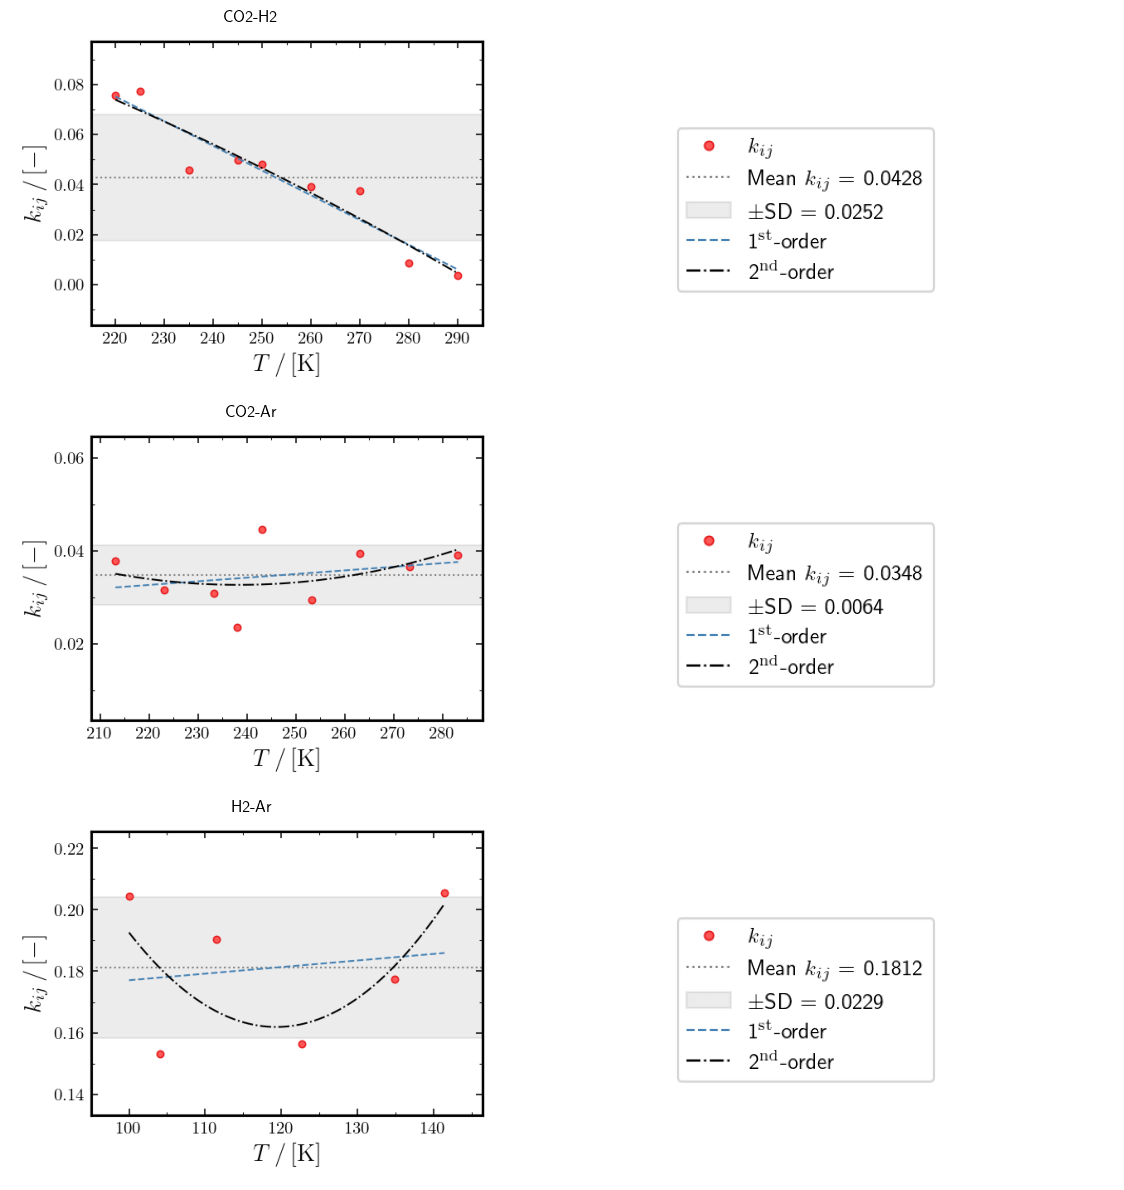

In [2]:
# --- Component & Feed Setup ---
COMPONENTS      = ["carbon dioxide", "hydrogen", "argon"]
ALL_COMPONENTS  = ["carbon dioxide", "hydrogen", "argon"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

KIJ_map = {
    ("CO2", "Ar") : "constant",
    ("H2",  "Ar") : "zero",
    ("CO2", "H2") : "zero",
}

CO2_comp = 0.95
feeds    = CompositionHandler.make_feeds([CO2_comp, 0.02, 0.03])

# --- Computation settings ---
T_initial_guess = 200
T_STEP          = 1        # Temperature step for phase envelope [K] (fine for accurate curves)
P_TOL           = 1e-4     # Pressure tolerance for flash [bar]
lgrid           = 100      # cDFT domain length [Angstrom]
ngrid           = 2048     # cDFT grid points
verbose         = True

# --- Shared resolution for cDFT and SEC colormaps ---
N_T = 30               # Number of temperature points in PT sweep
N_P = 30               # Number of pressure points per isotherm
                        # Grid size: 30 x 30 = 900 points max

CSV_FOLDER = "CSV_combined_constant_feed"
Path(CSV_FOLDER).mkdir(parents=True, exist_ok=True)

# --- KIJ builder & display ---
builder    = KIJ.KIJMatrixBuilder(root=str(KIJ_DIR), kij_filename="KIJ.json", verbose=False)
parameters = PARAMETERS(COMPONENTS, T_K=300.0, kij_builder=builder, model_map=KIJ_map)
components = RegistryManager.get_component_names(parameters)
KIJ_LABELS = RegistryManager.kij_labels_from_names(COMPONENTS)

builder.build_and_display(
    components=KIJ_LABELS,
    model_map=KIJ_map,
    T_eval=300.0,
    show_matrix=True,
    show_pair_equations=True,
)
CompositionHandler.print_array2d(feeds)
builder.show_pair_plots(KIJ_LABELS, mode="all")

## Phase Envelope (Bubble & Dew Curves)

In [3]:
# --- Phase envelope computation with T-dependent kij ---
PT_results = {}
VLE_DFT    = {}

for k, z in enumerate(feeds, start=1):
    z    = CompositionHandler.normalize_z(z)
    feed = CompositionHandler.compute_feed_moles(z)

    if verbose:
        print(f"\nFeed {k}: z = {z}")

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map  = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    parameters_ref = PARAMETERS(active_components, T_K=T_initial_guess, kij_builder=builder, model_map=active_map)
    eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters_ref)

    try:
        CT, CP = VLECalculator.compute_critical_point(eos, active_z, T_guess=T_initial_guess)

        if verbose:
            print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")

        T_values = range(int(T_initial_guess), int(CT / si.KELVIN) + 1, T_STEP)
        T_bubble_all, P_bubble_all = [], []
        T_dew_all, P_dew_all = [], []

        for T_K in T_values:
            parameters_T = PARAMETERS(active_components, T_K=float(T_K), kij_builder=builder, model_map=active_map)
            eos_T = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)

            T_bub, P_bub = VLECalculator.compute_bubble_curve(eos_T, [T_K], active_feed, verbose=verbose)
            T_dew, P_dew = VLECalculator.compute_dew_curve(eos_T, [T_K], active_feed, verbose=verbose)

            T_bubble_all.extend(T_bub); P_bubble_all.extend(P_bub)
            T_dew_all.extend(T_dew);    P_dew_all.extend(P_dew)

        PT_results[f"feed_{k}"] = {
            "z":      [round(float(x), 6) for x in np.asarray(z, dtype=float)],
            "TC_K":   round(float(CT / si.KELVIN), 2),
            "PC_bar": round(float(CP / si.BAR), 2),
            "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble_all, P_bubble_all)],
            "dew":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_all, P_dew_all)],
        }

    except Exception as e:
        print(f"Feed {k}: z = {z}")
        print("CT computation failed:", e)


Feed 1: z = [0.95 0.02 0.03]
Critical Point: T = 305.78 K, P = 91.58 bar


Bubble calculation failed at T = 297 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 301 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 303 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 303 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 305 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 305 K: Iteration resulted in trivial solution.


## Part 1: cDFT IFT across PT Phase Space


feed_1: cDFT sweep with N_T=30, N_P=30
T = 200.0 K | P_flash = 2.55 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 2.55 bar | gamma = 19.882591 mN/m
T = 200.0 K | P_flash = 4.64 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 4.64 bar | gamma = 19.494812 mN/m
T = 200.0 K | P_flash = 6.74 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 6.74 bar | gamma = 19.132859 mN/m
T = 200.0 K | P_flash = 8.83 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 8.83 bar | gamma = 18.796062 mN/m
T = 200.0 K | P_flash = 10.93 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 10.93 bar | gamma = 18.483381 mN/m
T = 200.0 K | P_flash = 13.02 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 13.02 bar | gamma = 18.193345 mN/m
T = 200.0 K | P_flash = 15.12 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 15.12 bar | gamma = 17.924183 mN/m
T = 200.0 K | P_flash = 17.21 | z = [0.95 0.02 0.03]
T = 200.0 K | P_flash = 17.21 bar | gamma = 17.673954 mN/m
T = 200.0 K | P_flash = 19.31 | z = [0.95 0.02 0.03]
T = 200.0 K | P_fla

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.120275862069 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


T = 300.1 K | P_flash = 90.08 | z = [0.95 0.02 0.03]
TP flash failed at T=300.1 K, P=90.08 bar: No phase split according to stability analysis.
T = 300.1 K | P_flash = 90.02 | z = [0.95 0.02 0.03]
TP flash failed at T=300.1 K, P=90.02 bar: No phase split according to stability analysis.
T = 300.1 K | P_flash = 89.96 | z = [0.95 0.02 0.03]
TP flash failed at T=300.1 K, P=89.96 bar: No phase split according to stability analysis.
T = 300.1 K | P_flash = 89.90 | z = [0.95 0.02 0.03]
TP flash failed at T=300.1 K, P=89.90 bar: No phase split according to stability analysis.
T = 300.1 K | P_flash = 89.84 | z = [0.95 0.02 0.03]
TP flash failed at T=300.1 K, P=89.84 bar: No phase split according to stability analysis.
T = 300.1 K | P_flash = 89.77 | z = [0.95 0.02 0.03]
TP flash failed at T=300.1 K, P=89.77 bar: No phase split according to stability analysis.
T = 300.1 K | P_flash = 89.71 | z = [0.95 0.02 0.03]
TP flash failed at T=300.1 K, P=89.71 bar: No phase split according to stability an

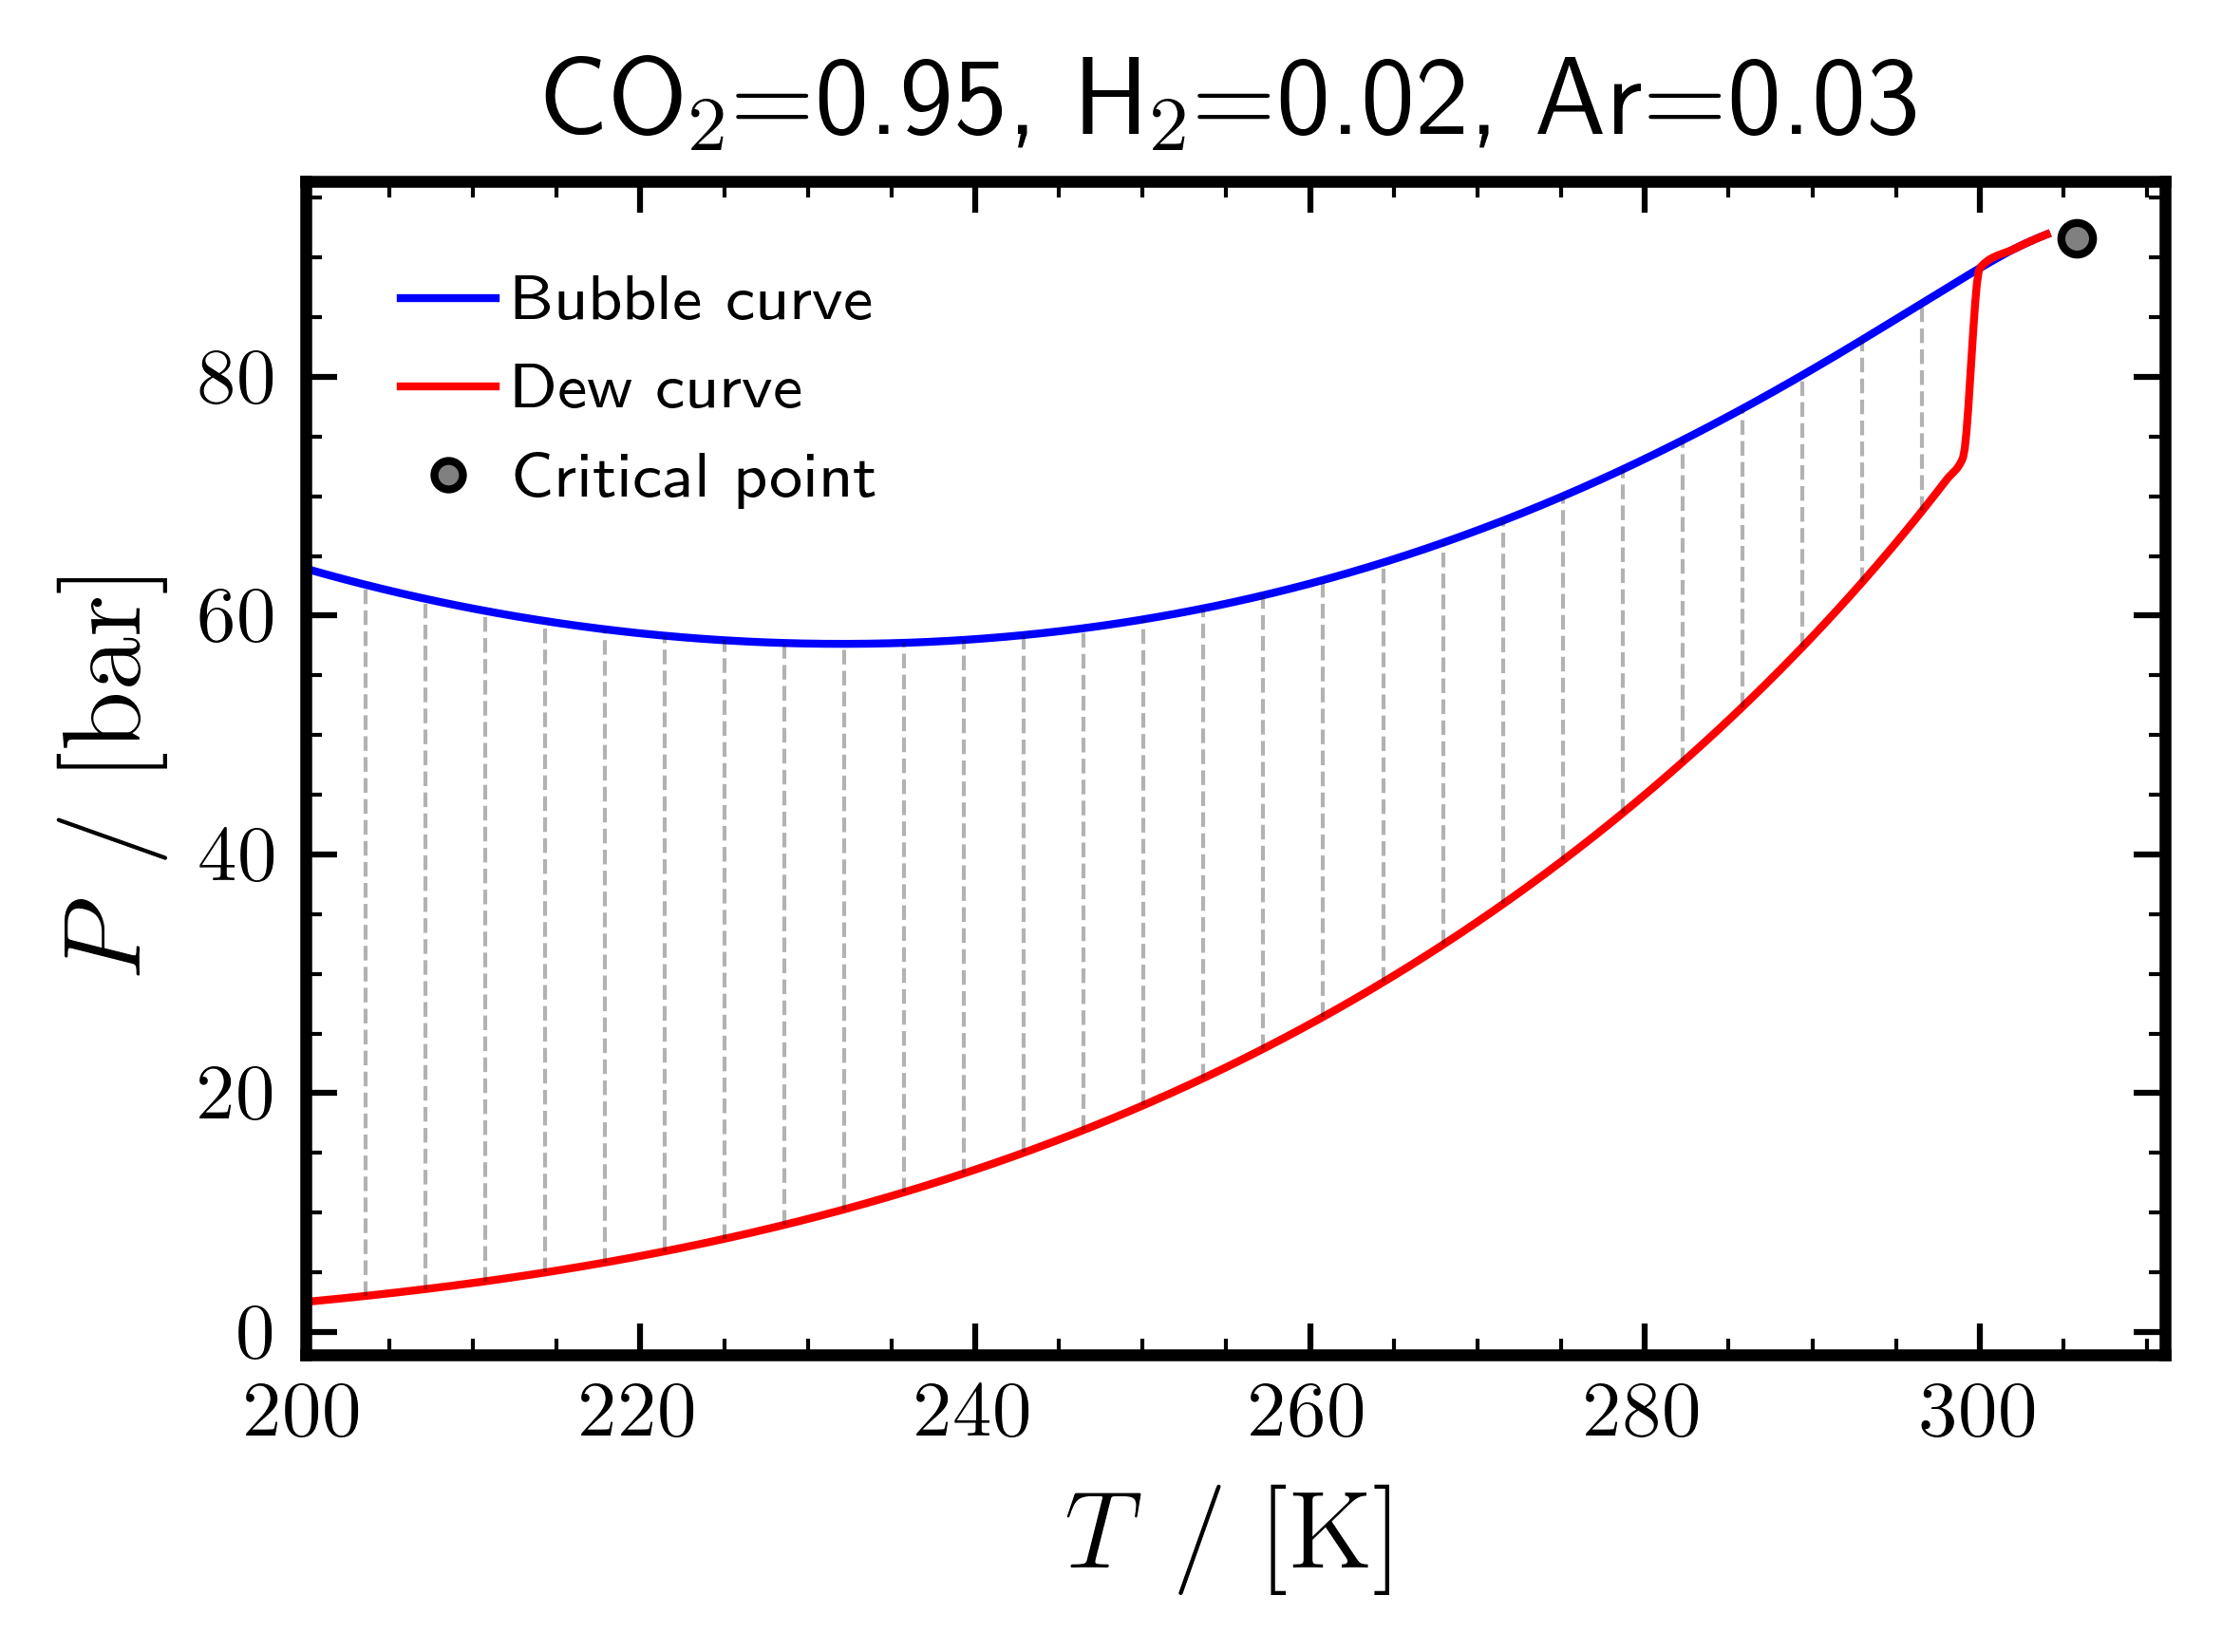

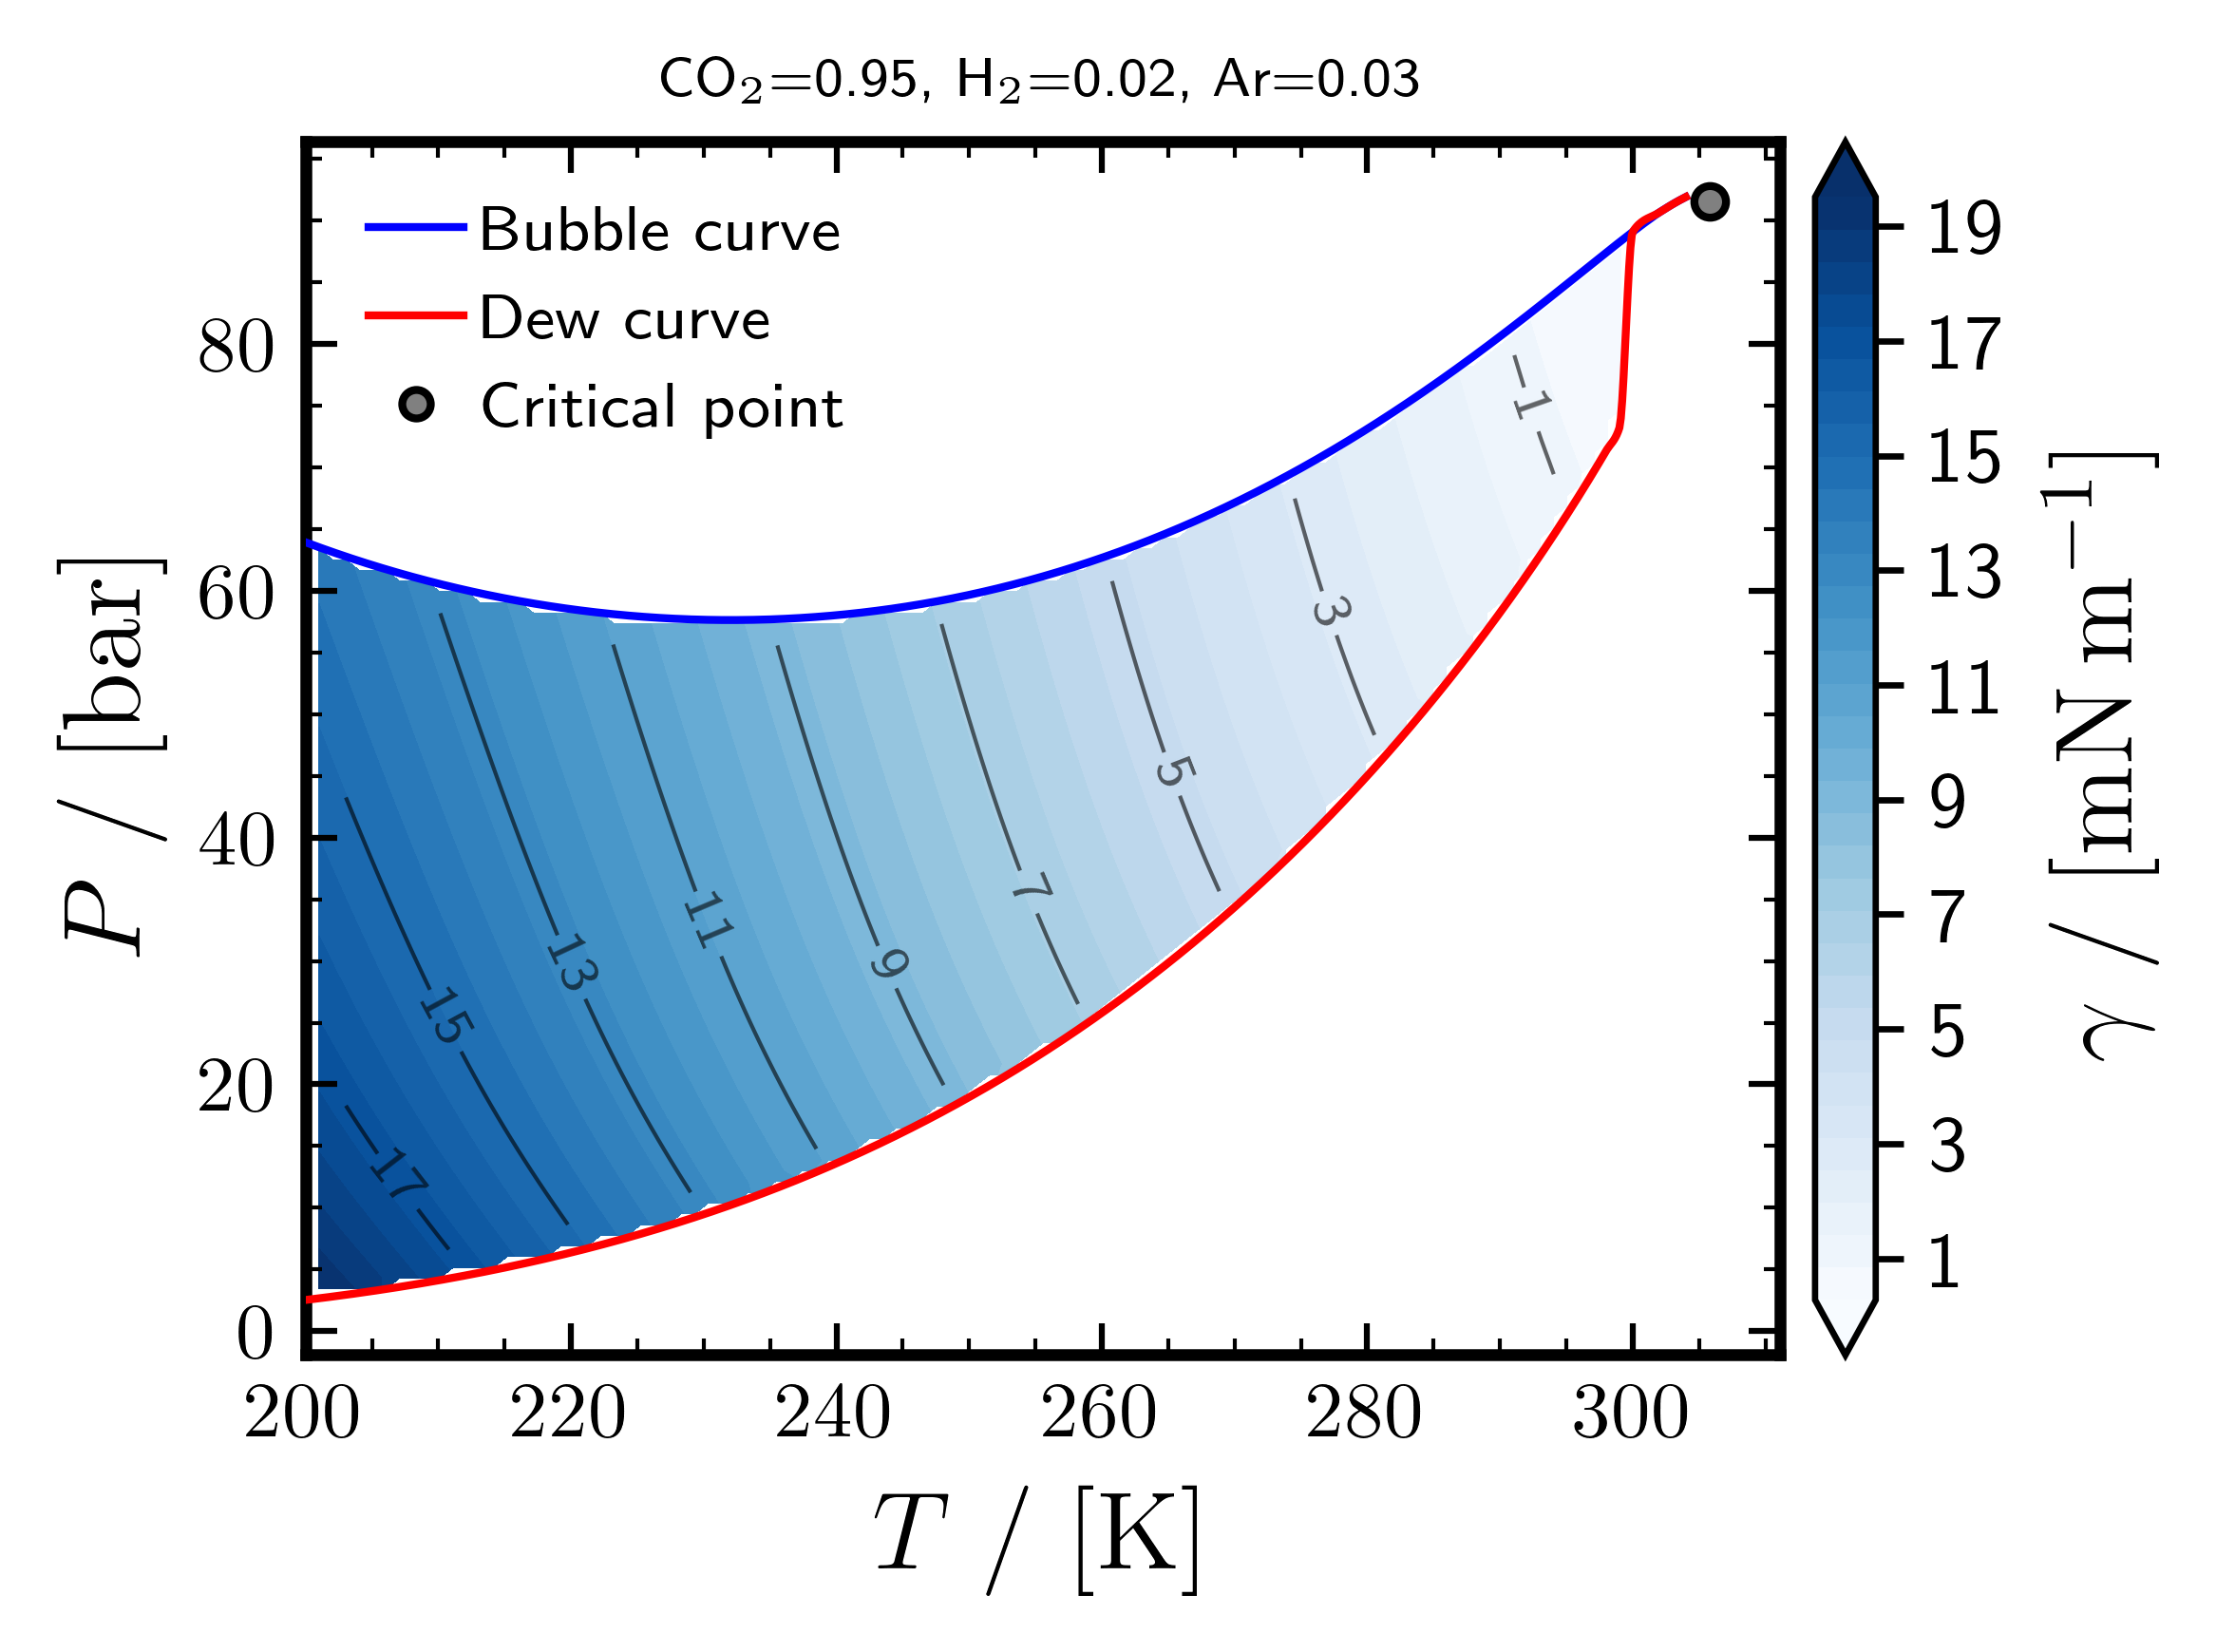

In [4]:
# --- cDFT: PT space sweep, TP flash, and planar interface IFT ---
# Uses the same N_T x N_P grid as the SEC colormaps for direct comparison.

sec_cdft = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid)

for feed_key, feed in PT_results.items():

    TP_z = np.array(feed.get("z", []))
    CT   = feed["TC_K"] * si.KELVIN
    CP   = feed["PC_bar"] * si.BAR

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(TP_z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map  = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    fig, ax = PlottingEngine.plot_phase_diagram(PT_results, feed_key, parameters)

    # Build interpolation arrays from phase envelope (fine resolution from T_STEP=1)
    bub_pts = sorted(feed.get("bubble", []), key=lambda p: p["T_K"])
    dew_pts = sorted(feed.get("dew", []),    key=lambda p: p["T_K"])
    T_bub_arr = np.array([p["T_K"]  for p in bub_pts])
    P_bub_arr = np.array([p["P_bar"] for p in bub_pts])
    T_dew_arr = np.array([p["T_K"]  for p in dew_pts])
    P_dew_arr = np.array([p["P_bar"] for p in dew_pts])

    # Shared T grid (same as SEC uses internally)
    T_min = max(T_bub_arr.min(), T_dew_arr.min())
    T_max = min(T_bub_arr.max(), T_dew_arr.max()) * 0.999
    T_grid = np.linspace(T_min, T_max, N_T)

    VLE_DFT[feed_key] = {
        "z": TP_z.tolist(),
        "phase_envelope": {
            "bubble_curve": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bub_arr, P_bub_arr)],
            "dew_curve":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_arr, P_dew_arr)],
            "isothermal_lines": []
        },
        "interfacial_data": {}
    }

    if verbose:
        print(f"\n{feed_key}: cDFT sweep with N_T={N_T}, N_P={N_P}")

    for T_K in T_grid:
        # Interpolate bubble/dew pressures at this T
        P_b = float(np.interp(T_K, T_bub_arr, P_bub_arr))
        P_d = float(np.interp(T_K, T_dew_arr, P_dew_arr))

        if P_b <= P_d:
            continue

        T = int(round(T_K))  # integer key for storage

        VLE_DFT[feed_key]["phase_envelope"]["isothermal_lines"].append(
            {"T_K": float(T_K), "P_bubble_bar": P_b, "P_dew_bar": P_d}
        )

        # Rebuild parameters with T-dependent kij
        parameters_T = PARAMETERS(active_components, T_K=float(T_K), kij_builder=builder, model_map=active_map)
        eos_T        = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
        molar_masses = PropertyCalculator.molar_masses(parameters_T)

        # --- Pure CO2 properties at this temperature ---
        gamma0_CO2, rhoL0_CO2, rhoV0_CO2, Tc_CO2, Pc_CO2, Psat_CO2 = \
            sec_cdft._pure_component_cDFT("carbon dioxide", float(T_K))

        pressures = np.linspace(P_d * 1.01, P_b * 0.99, N_P)
        ax.plot([T_K, T_K], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)

        VLE_DFT[feed_key]["interfacial_data"][T_K] = []

        for P in pressures:
            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} | z = {active_z}")

            try:
                eq, x, y, liquid_density, vapor_density = VLECalculator.tp_flash(
                    eos_T, T_K*si.KELVIN, P*si.BAR, active_z*si.MOL, molar_masses)
            except Exception as e:
                print(f"TP flash failed at T={T_K:.1f} K, P={P:.2f} bar: {e}")
                continue

            interface = InterfacialTensionCalculator.build_planar_interface(
                eq, critical_temperature=CT, n_grid=ngrid, l_grid=lgrid)

            try:
                gamma_mN_m, interfacial_thickness_nm, enrichment = \
                    InterfacialTensionCalculator.solve_interface_properties(interface)
            except Exception as e:
                print(f"IFT failed at T={T_K:.1f} K, P={P:.2f} bar: {e}")
                gamma_mN_m = np.nan
                interfacial_thickness_nm = np.nan
                enrichment = tuple(np.nan for _ in active_components)

            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

            row_data = DataProcessor.assemble_row(
                T_K, P, active_z, CT, CP, P_b, P_d,
                liquid_density, vapor_density,
                x, y, gamma_mN_m, interfacial_thickness_nm,
                active_components, enrichment,
                gamma0_CO2=gamma0_CO2,
                rhoL0_CO2_mol_cm3=rhoL0_CO2,
                rhoV0_CO2_mol_cm3=rhoV0_CO2,
                Tc_CO2=Tc_CO2,
                Psat_CO2=Psat_CO2,
                ML_mode=False,
            )
            VLE_DFT[feed_key]["interfacial_data"][T_K].append(row_data)

    PlottingEngine.save_plots(fig, f"PT_{feed_key}", folder=CSV_FOLDER)

    fig_gamma = PlottingEngine.plot_interfacial_tension_map(PT_results, VLE_DFT, feed_key, parameters)
    if fig_gamma is not None:
        PlottingEngine.save_plots(fig_gamma, f"Gamma_cDFT_{feed_key}", folder=CSV_FOLDER)

summary = DataProcessor.summarize_vle_dft(VLE_DFT)
if verbose:
    print(summary)

saved_files = DataProcessor.export_to_csv(VLE_DFT, folder=CSV_FOLDER, verbose=verbose)

## Part 2: SEC IFT Colormaps (Parachor T-dependent & WSD)

In [5]:
# --- SEC: Compute PT colormap data for each feed ---
# Uses the same N_T x N_P resolution as the cDFT sweep.

feed_key = list(PT_results.keys())[0]
feed     = PT_results[feed_key]

Tc_K   = feed["TC_K"]
Pc_bar = feed["PC_bar"]

# Extract bubble/dew arrays from PT_results
T_bub_all = [pt["T_K"]  for pt in feed["bubble"]]
P_bub_all = [pt["P_bar"] for pt in feed["bubble"]]
T_dew_all = [pt["T_K"]  for pt in feed["dew"]]
P_dew_all = [pt["P_bar"] for pt in feed["dew"]]

# Reference eos for SEC
params_ref = PARAMETERS(COMPONENTS, T_K=T_initial_guess, kij_builder=builder, model_map=KIJ_map)
eos_ref    = feos.HelmholtzEnergyFunctional.pcsaft(params_ref)

model = semi_emperical_correlations()

# --- Parachor (T-dependent) ---
data_parachor = model.compute_PT_colormap_data(
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub_all,
    P_bub=P_bub_all,
    T_dew=T_dew_all,
    P_dew=P_dew_all,
    method="parachor",
    n_exp=3.87,
    kij_parachor=0.0,
    n_T=N_T,
    n_P=N_P,
    recompute_parachor=True,
    kij_builder=builder,
    model_map=KIJ_map,
)

# --- WSD method (with correction) ---
data_wsd = model.compute_PT_colormap_data(
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub_all,
    P_bub=P_bub_all,
    T_dew=T_dew_all,
    P_dew=P_dew_all,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=True,
    n_T=N_T,
    n_P=N_P,
    kij_builder=builder,
    model_map=KIJ_map,
)

# --- WSD method (without correction) ---
data_wsd_nocorr = model.compute_PT_colormap_data(
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    eos=eos_ref,
    T_bub=T_bub_all,
    P_bub=P_bub_all,
    T_dew=T_dew_all,
    P_dew=P_dew_all,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=False,
    n_T=N_T,
    n_P=N_P,
    kij_builder=builder,
    model_map=KIJ_map,
)

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:238: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.120275862069 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


## SEC Colormap Plots

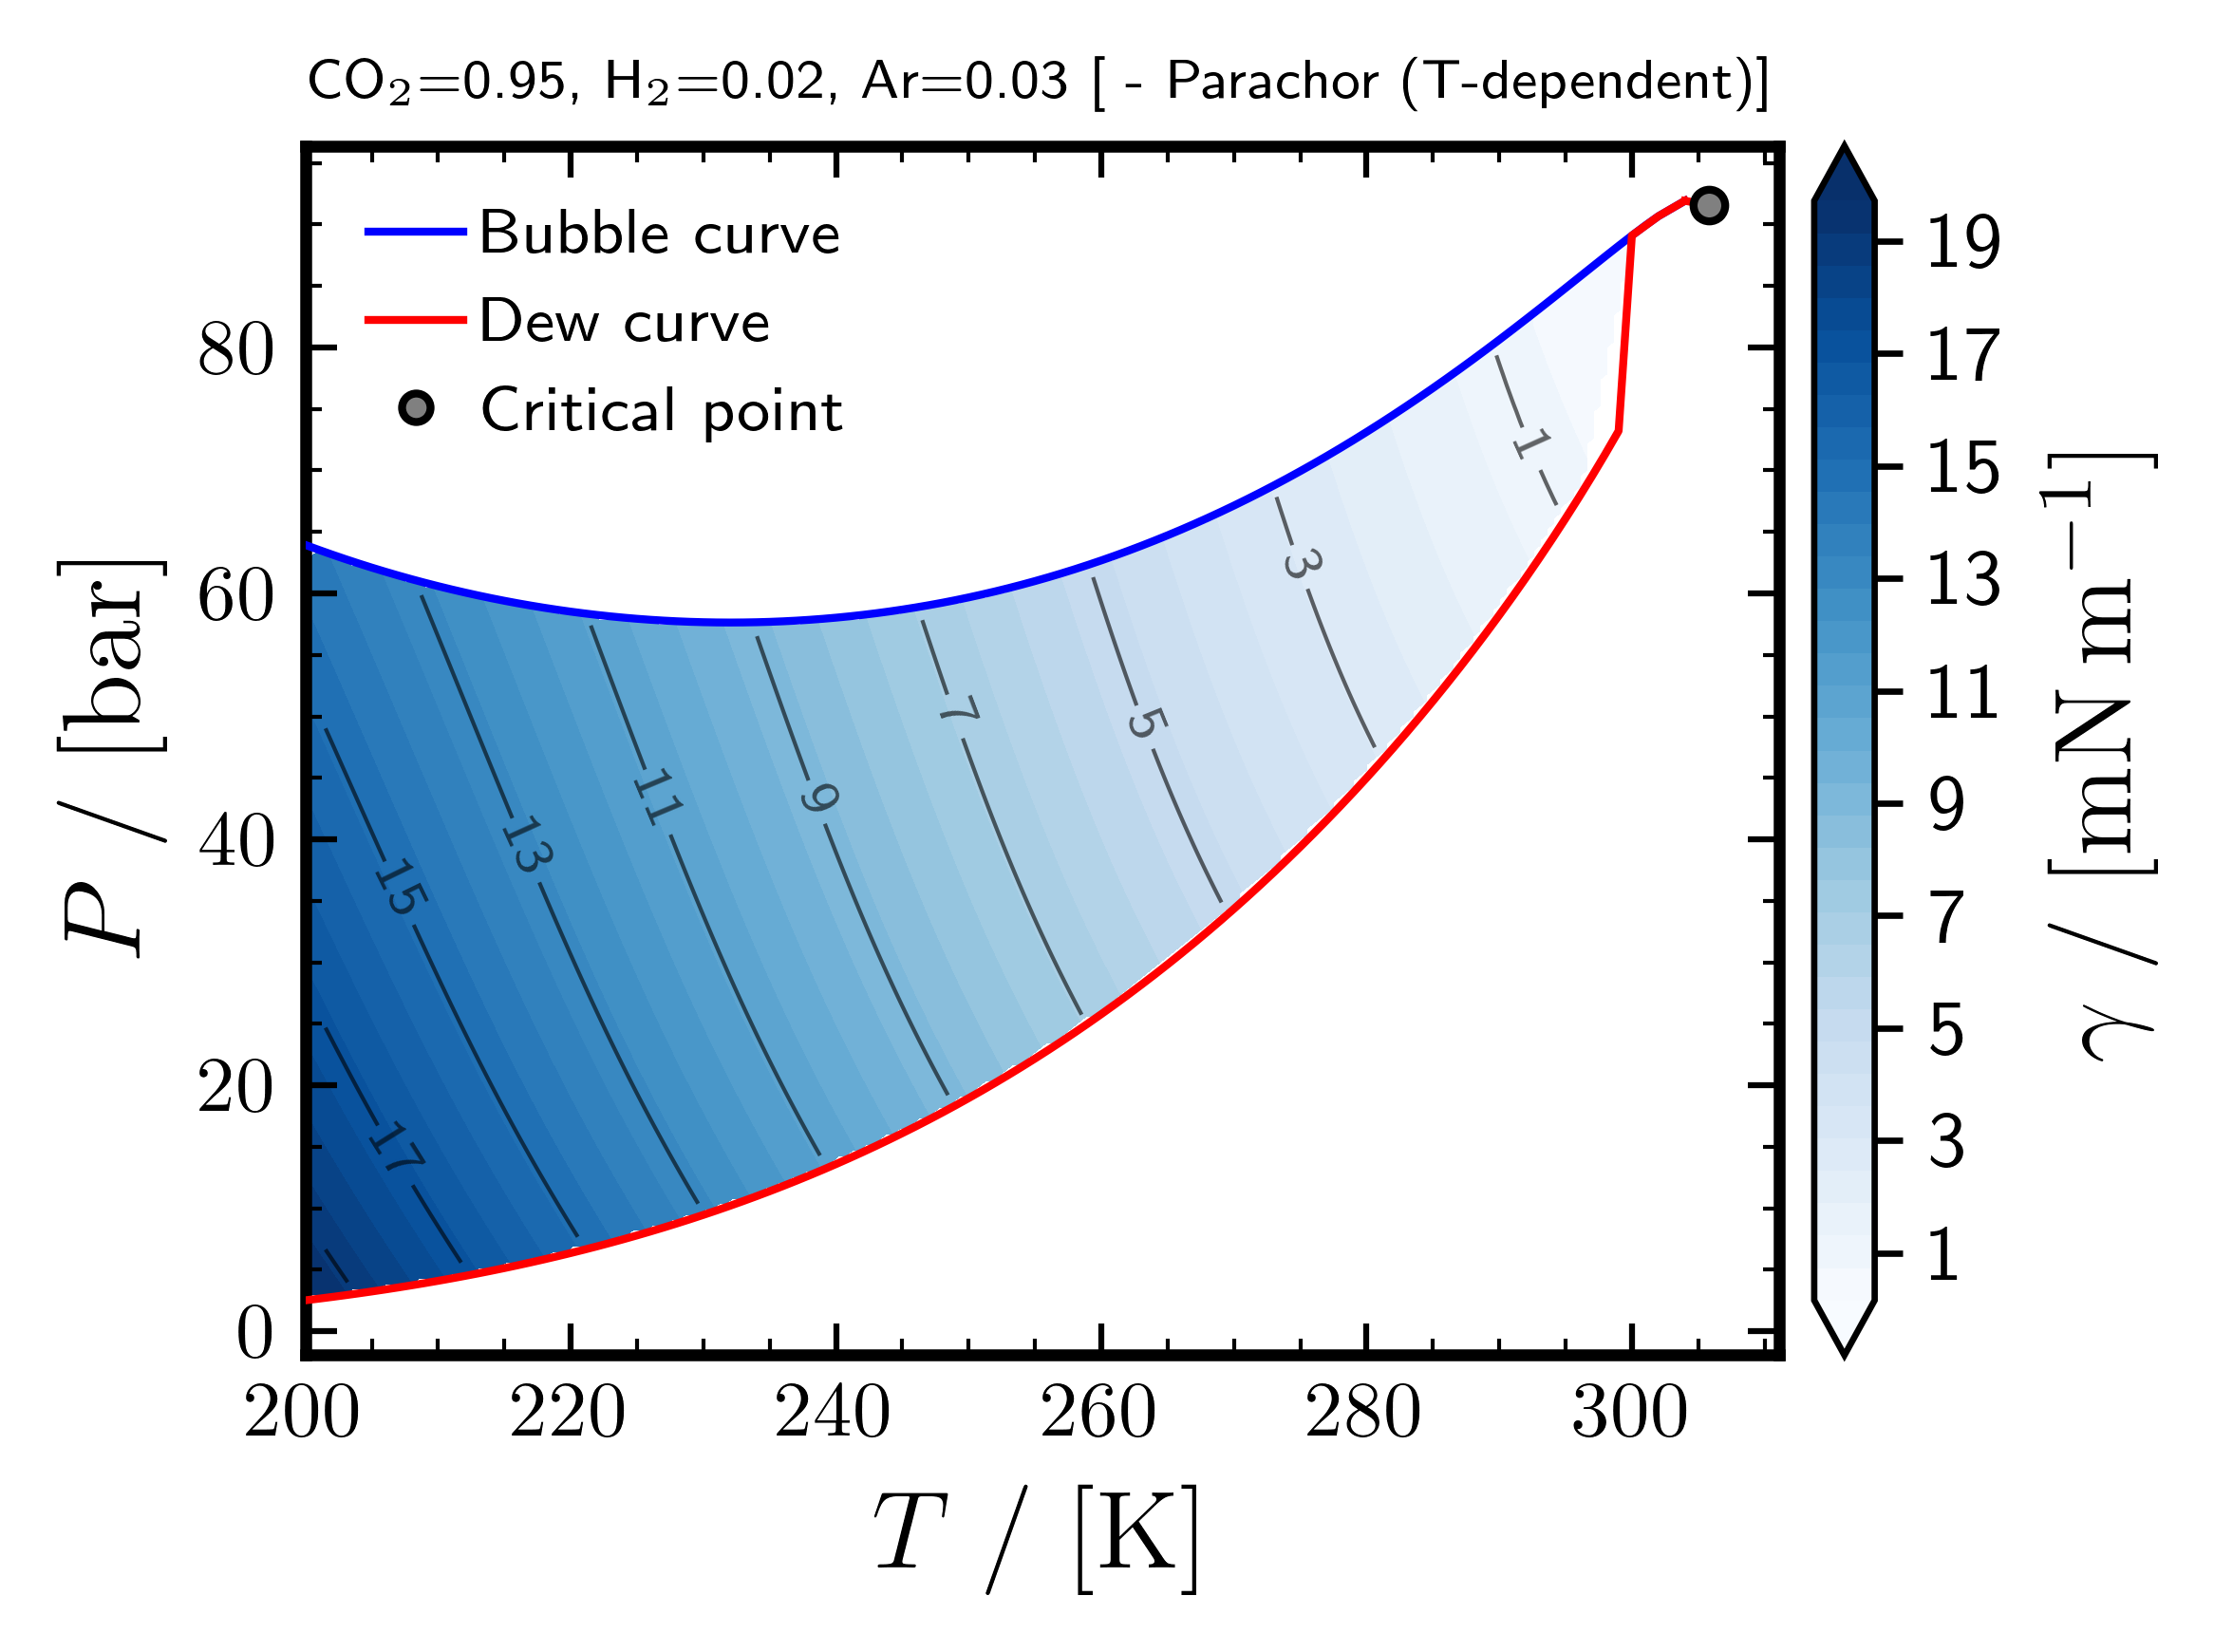

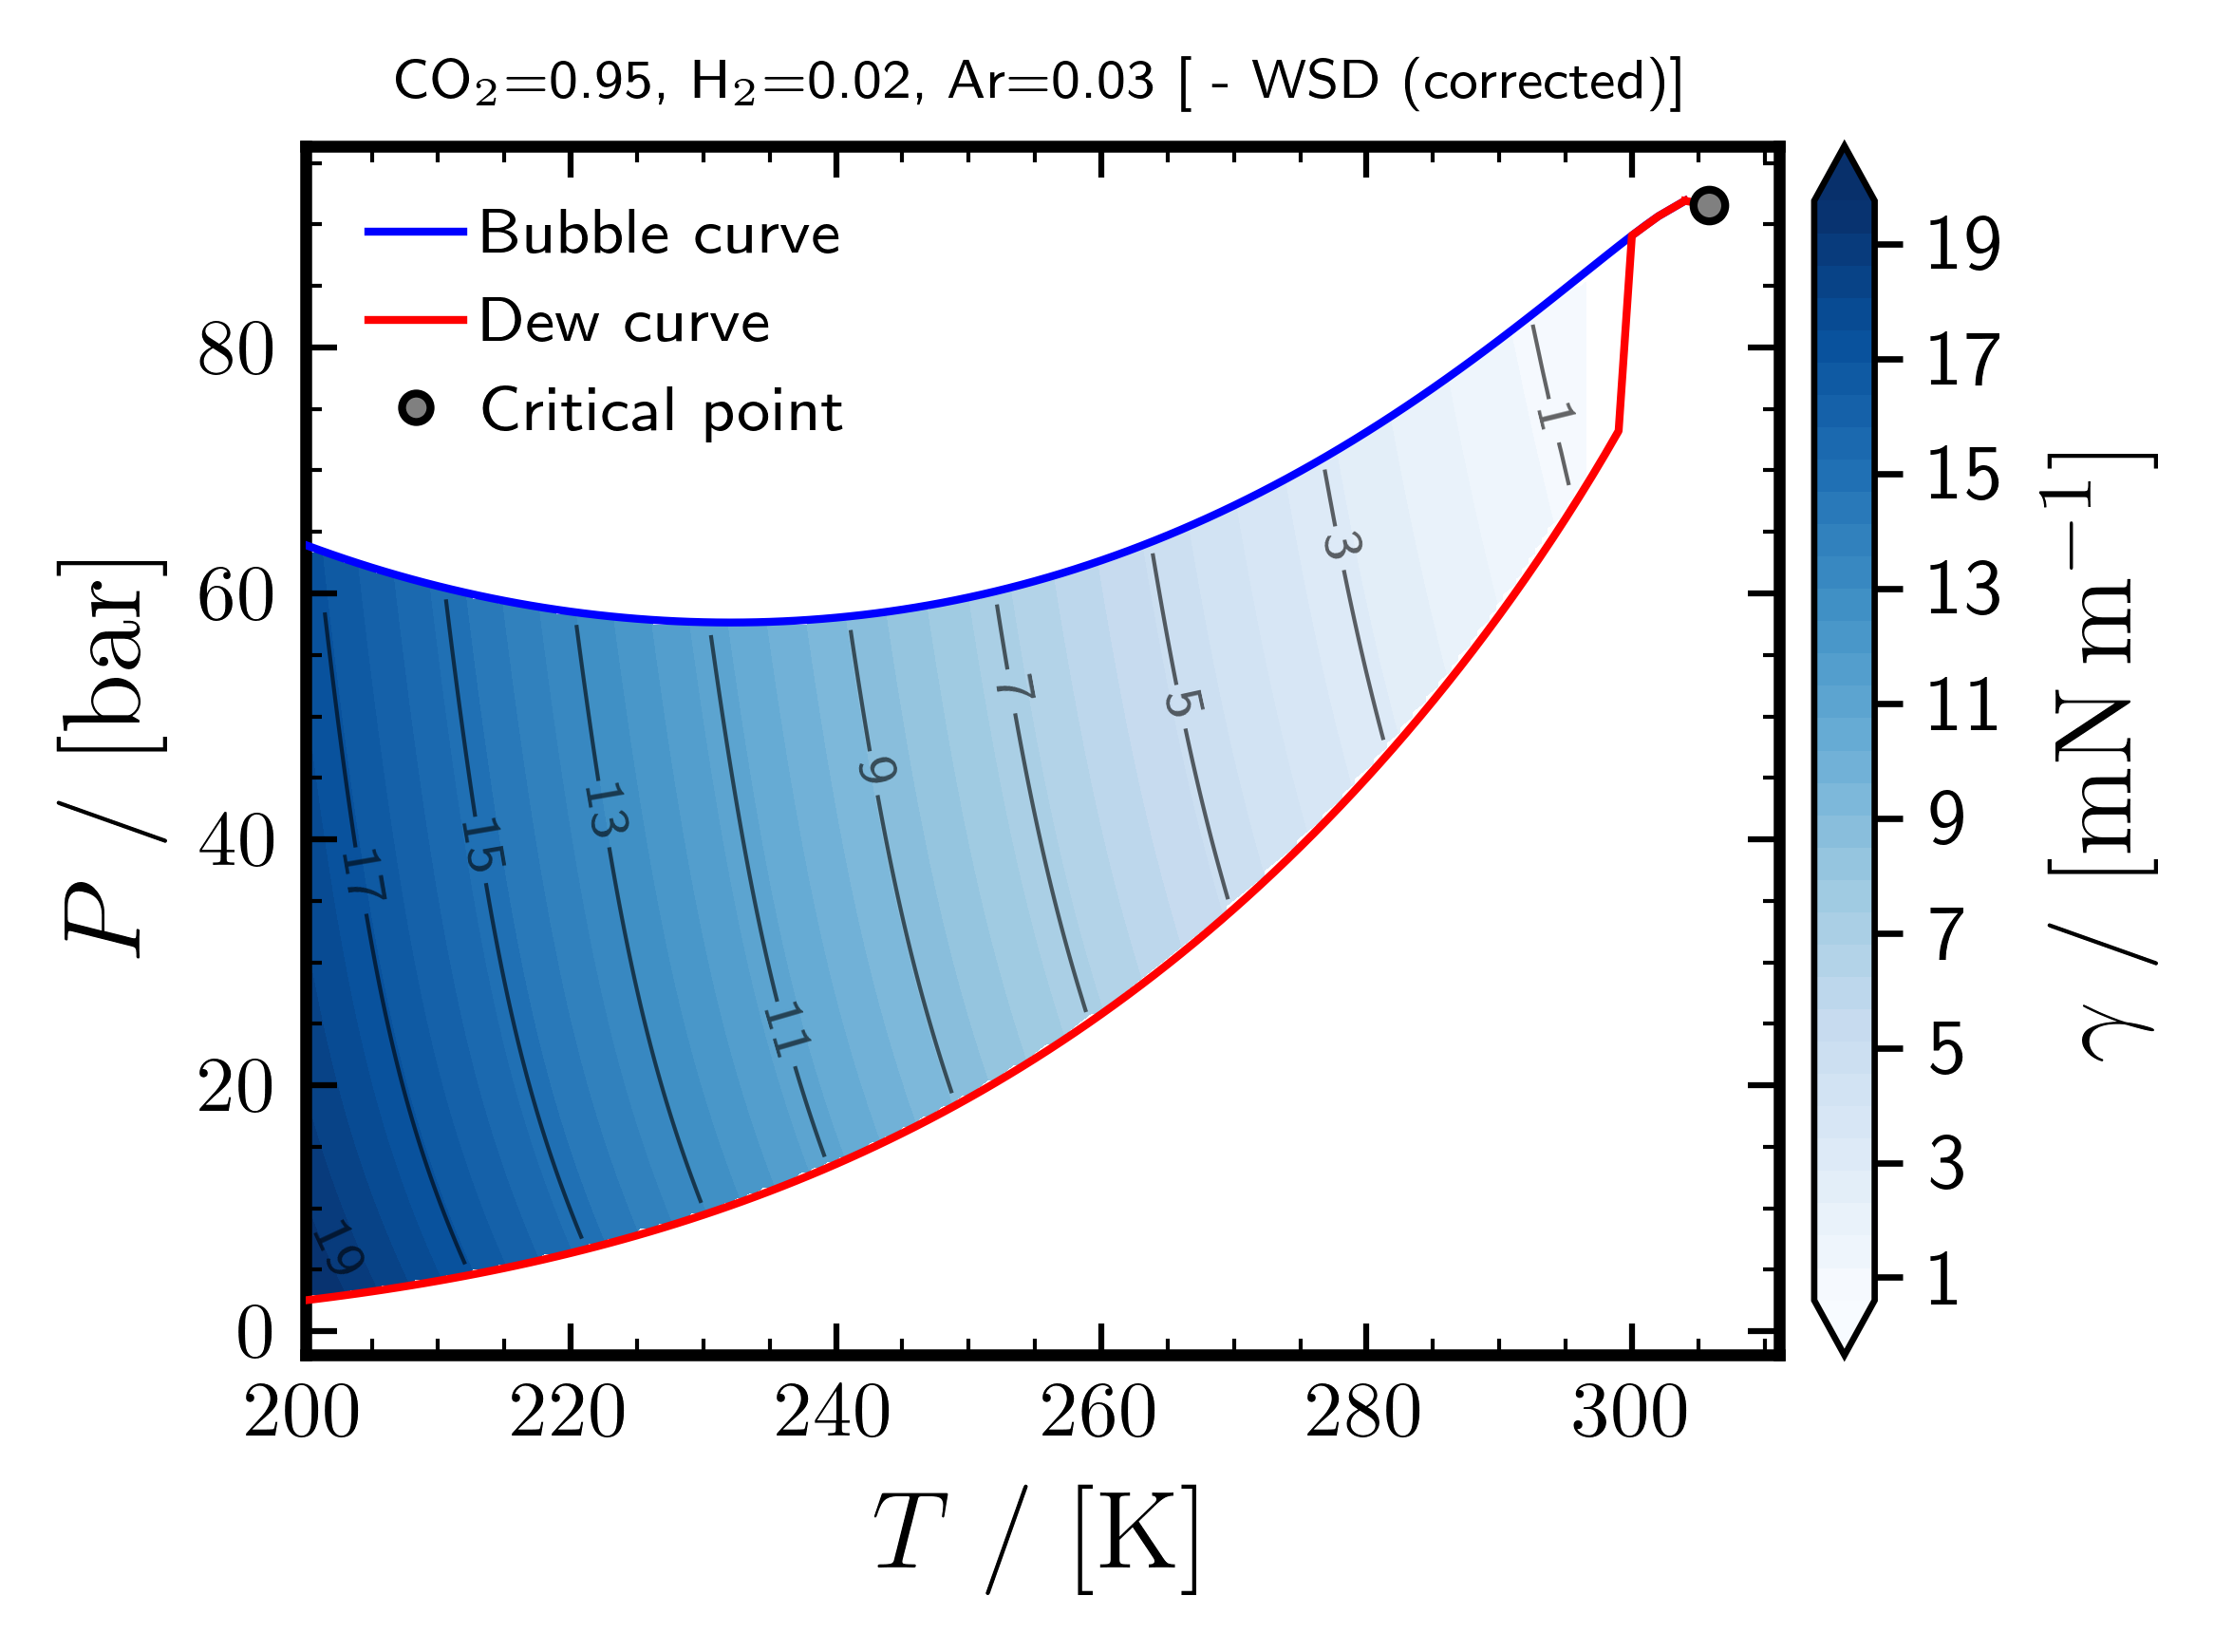

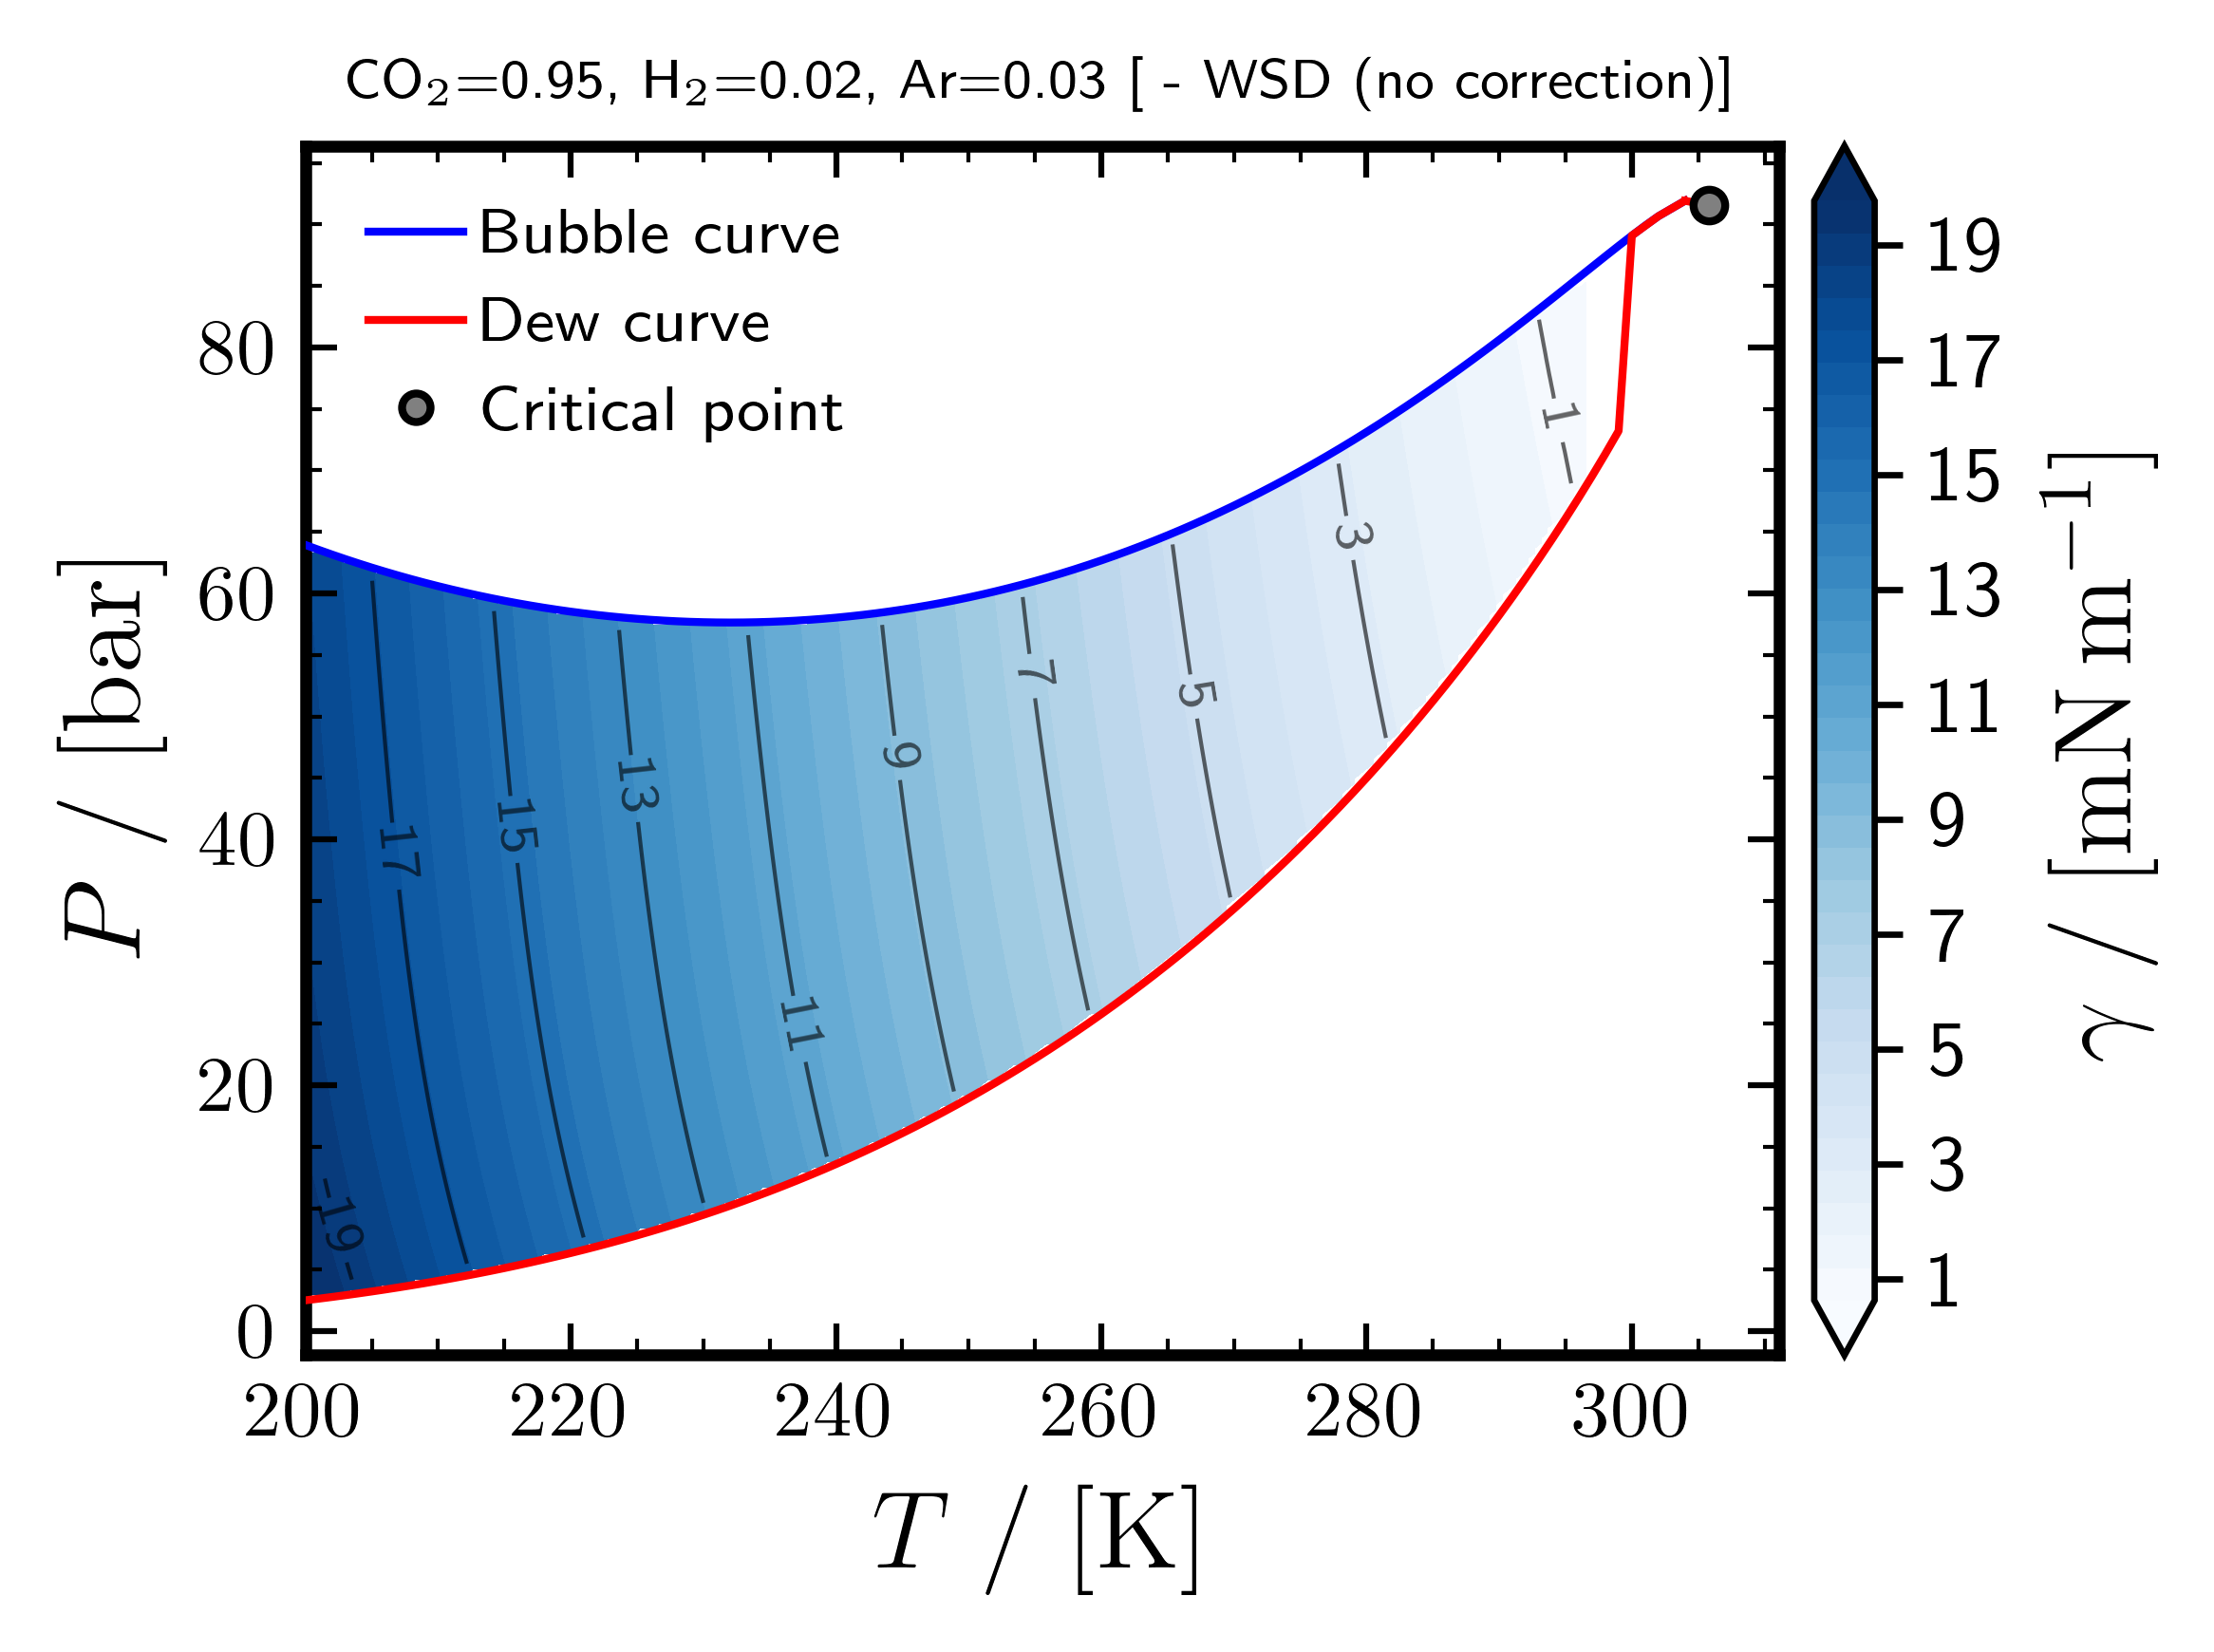

In [6]:
# --- SEC Colormap: Parachor (T-dependent) ---
fig1, ax1 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_parachor,
    T_bub=T_bub_all, P_bub=P_bub_all,
    T_dew=T_dew_all, P_dew=P_dew_all,
    Tc_K=Tc_K, Pc_bar=Pc_bar,
    params=params_ref, feed_z=FEED_Z,
    title_suffix=" - Parachor (T-dependent)",
)
plt.savefig(f"{CSV_FOLDER}/colormap_parachor_Tdep.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/colormap_parachor_Tdep.pdf", bbox_inches="tight")
plt.show()

# --- SEC Colormap: WSD (with correction) ---
fig2, ax2 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_wsd,
    T_bub=T_bub_all, P_bub=P_bub_all,
    T_dew=T_dew_all, P_dew=P_dew_all,
    Tc_K=Tc_K, Pc_bar=Pc_bar,
    params=params_ref, feed_z=FEED_Z,
    title_suffix=" - WSD (corrected)",
)
plt.savefig(f"{CSV_FOLDER}/colormap_wsd.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/colormap_wsd.pdf", bbox_inches="tight")
plt.show()

# --- SEC Colormap: WSD (without correction) ---
fig3, ax3 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_wsd_nocorr,
    T_bub=T_bub_all, P_bub=P_bub_all,
    T_dew=T_dew_all, P_dew=P_dew_all,
    Tc_K=Tc_K, Pc_bar=Pc_bar,
    params=params_ref, feed_z=FEED_Z,
    title_suffix=" - WSD (no correction)",
)
plt.savefig(f"{CSV_FOLDER}/colormap_wsd_nocorr.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{CSV_FOLDER}/colormap_wsd_nocorr.pdf", bbox_inches="tight")
plt.show()

## Save SEC Colormap DataFrames

In [7]:
# --- Save SEC PT colormap DataFrames ---
dfs_PT = SEC.semi_emperical_correlations.save_PT_colormap_dataframes(
    data_parachor=data_parachor,
    data_wsd=data_wsd,
    output_dir=CSV_FOLDER,
    component_names=COMPONENTS,
    feed_z=FEED_Z,
    n_exp=3.87,
    ML_mode=True,
    main_component_index=0,
    all_components=ALL_COMPONENTS,
)

df_PT_para = dfs_PT["PT_parachor"]
df_PT_wsd  = dfs_PT["PT_wsd"]

print("\nParachor (T-dep) columns:", list(df_PT_para.columns))
print("WSD columns:",              list(df_PT_wsd.columns))

Saved CSV_combined_constant_feed/PT_parachor.csv (855 rows, 30 cols)
Saved CSV_combined_constant_feed/PT_wsd.csv (840 rows, 26 cols)

Parachor (T-dep) columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'rhoL1_carbon dioxide', 'rhoL2_hydrogen', 'rhoL3_argon', 'rhoV1_carbon dioxide', 'rhoV2_hydrogen', 'rhoV3_argon', 'gamma0_carbon dioxide', 'rhoL0_carbon dioxide', 'rhoV0_carbon dioxide', 'Tc_carbon dioxide', 'Pc_carbon dioxide', 'Psat0_carbon dioxide', 'parachor_carbon dioxide', 'parachor_hydrogen', 'parachor_argon', 'n_exp', 'gamma_parachor']
WSD columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'rhoL1_carbon dioxide', 'rhoL2_hydrogen', 'rhoL3_argon', 'rhoV1_carbon dioxide', 'rhoV2_hydrogen', 'rhoV3_argon', 'gamma0_carbon dioxide', 'rhoL0_carbon 

## Difference Colormaps (cDFT vs SEC)
Compare cDFT and SEC methods by interpolating all onto a common grid and plotting the differences:
- **cDFT - Parachor**
- **cDFT - WSD (corrected)**
- **cDFT - WSD (no correction)**

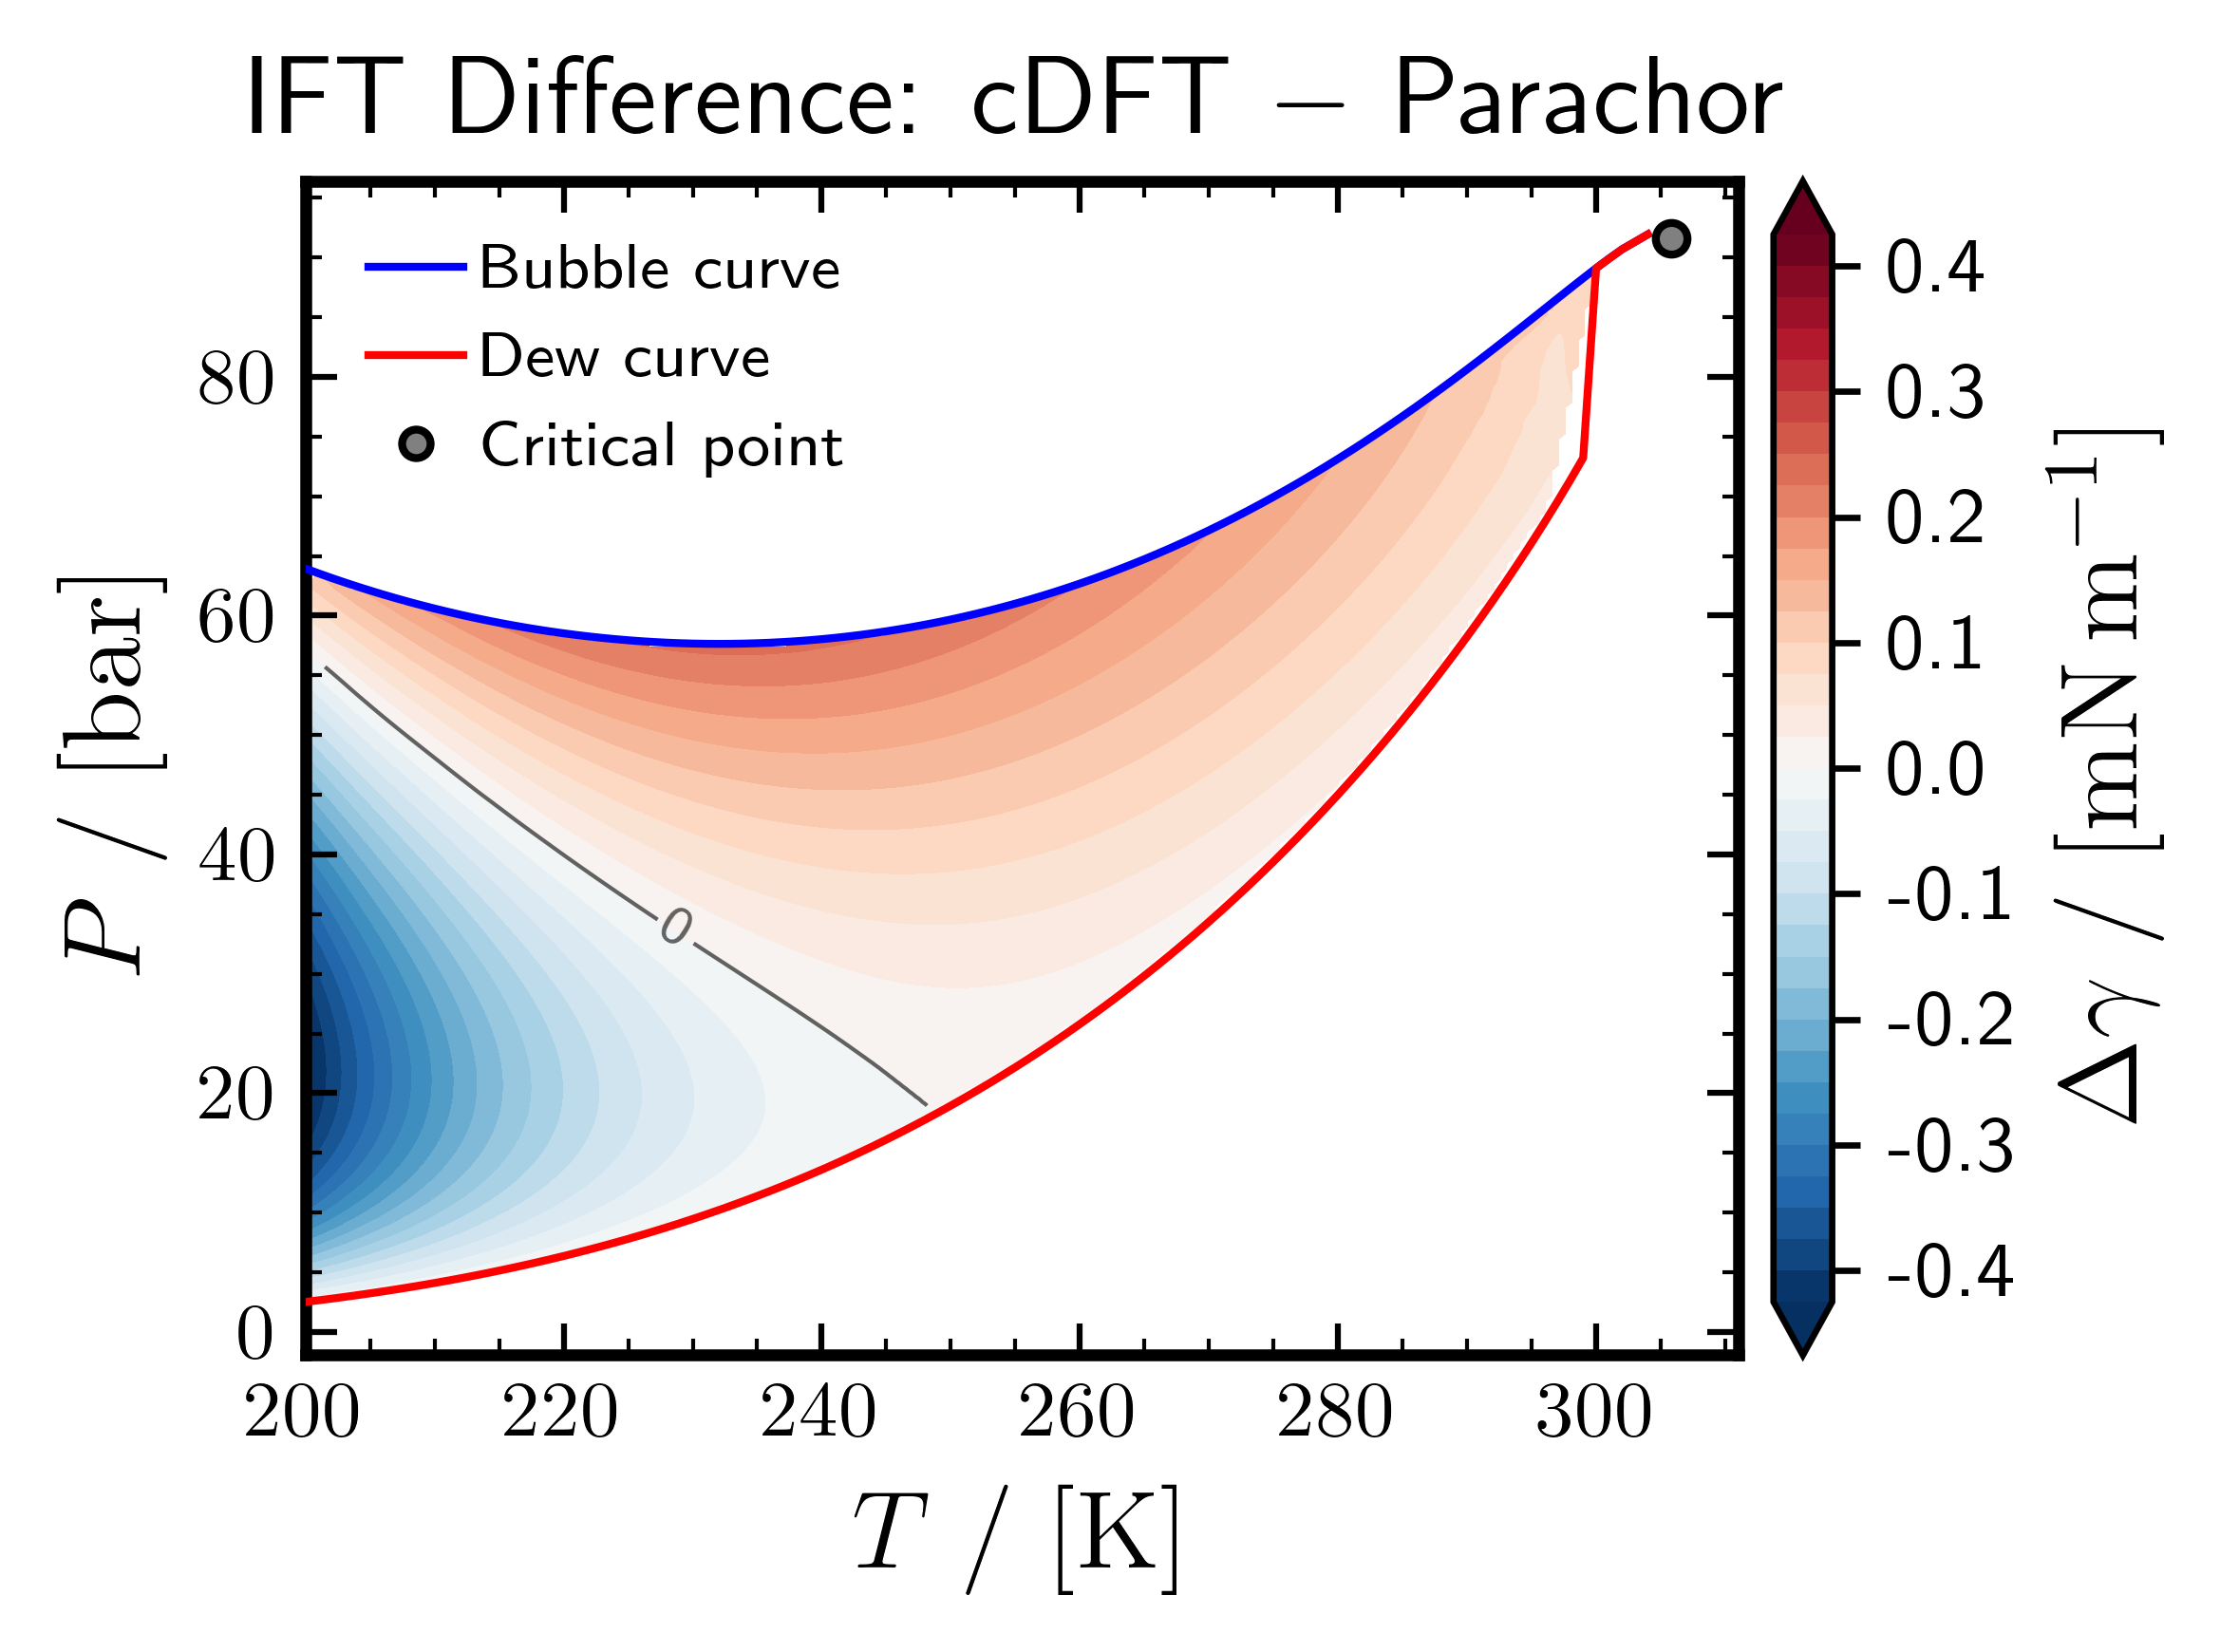

cDFT $-$ Parachor: range = [-0.38, 0.21] mN/m


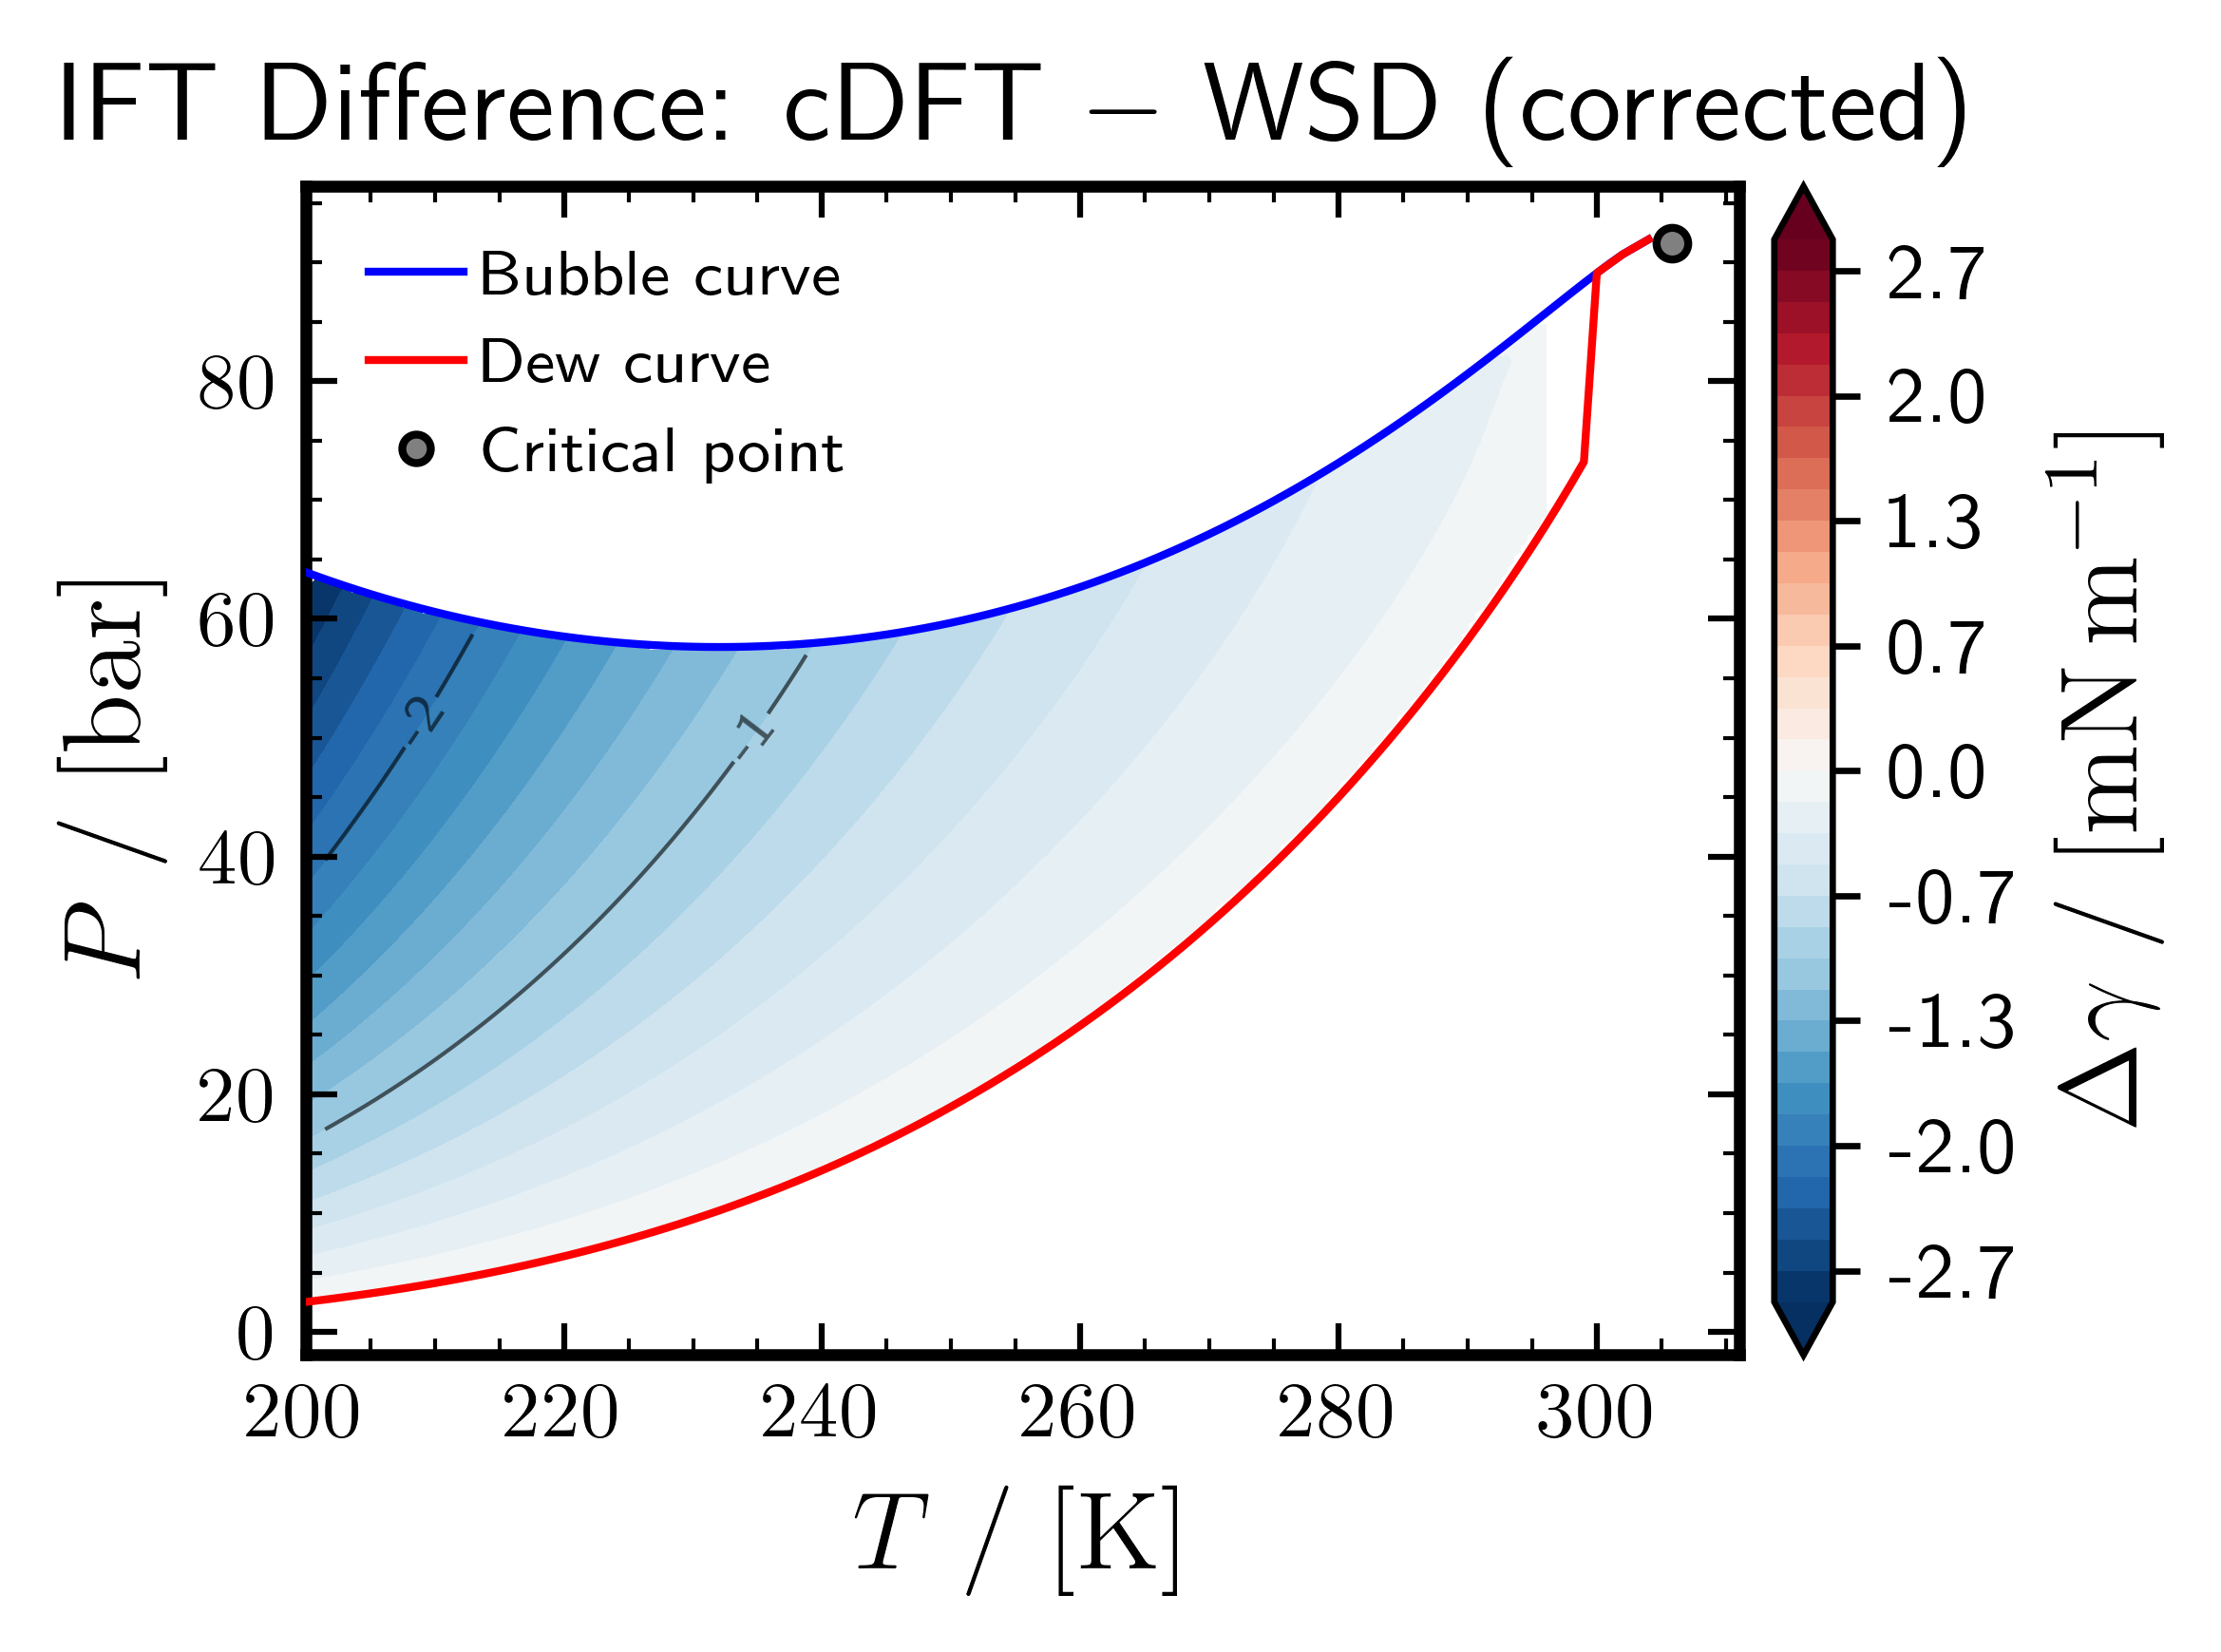

cDFT $-$ WSD (corrected): range = [-2.82, -0.02] mN/m


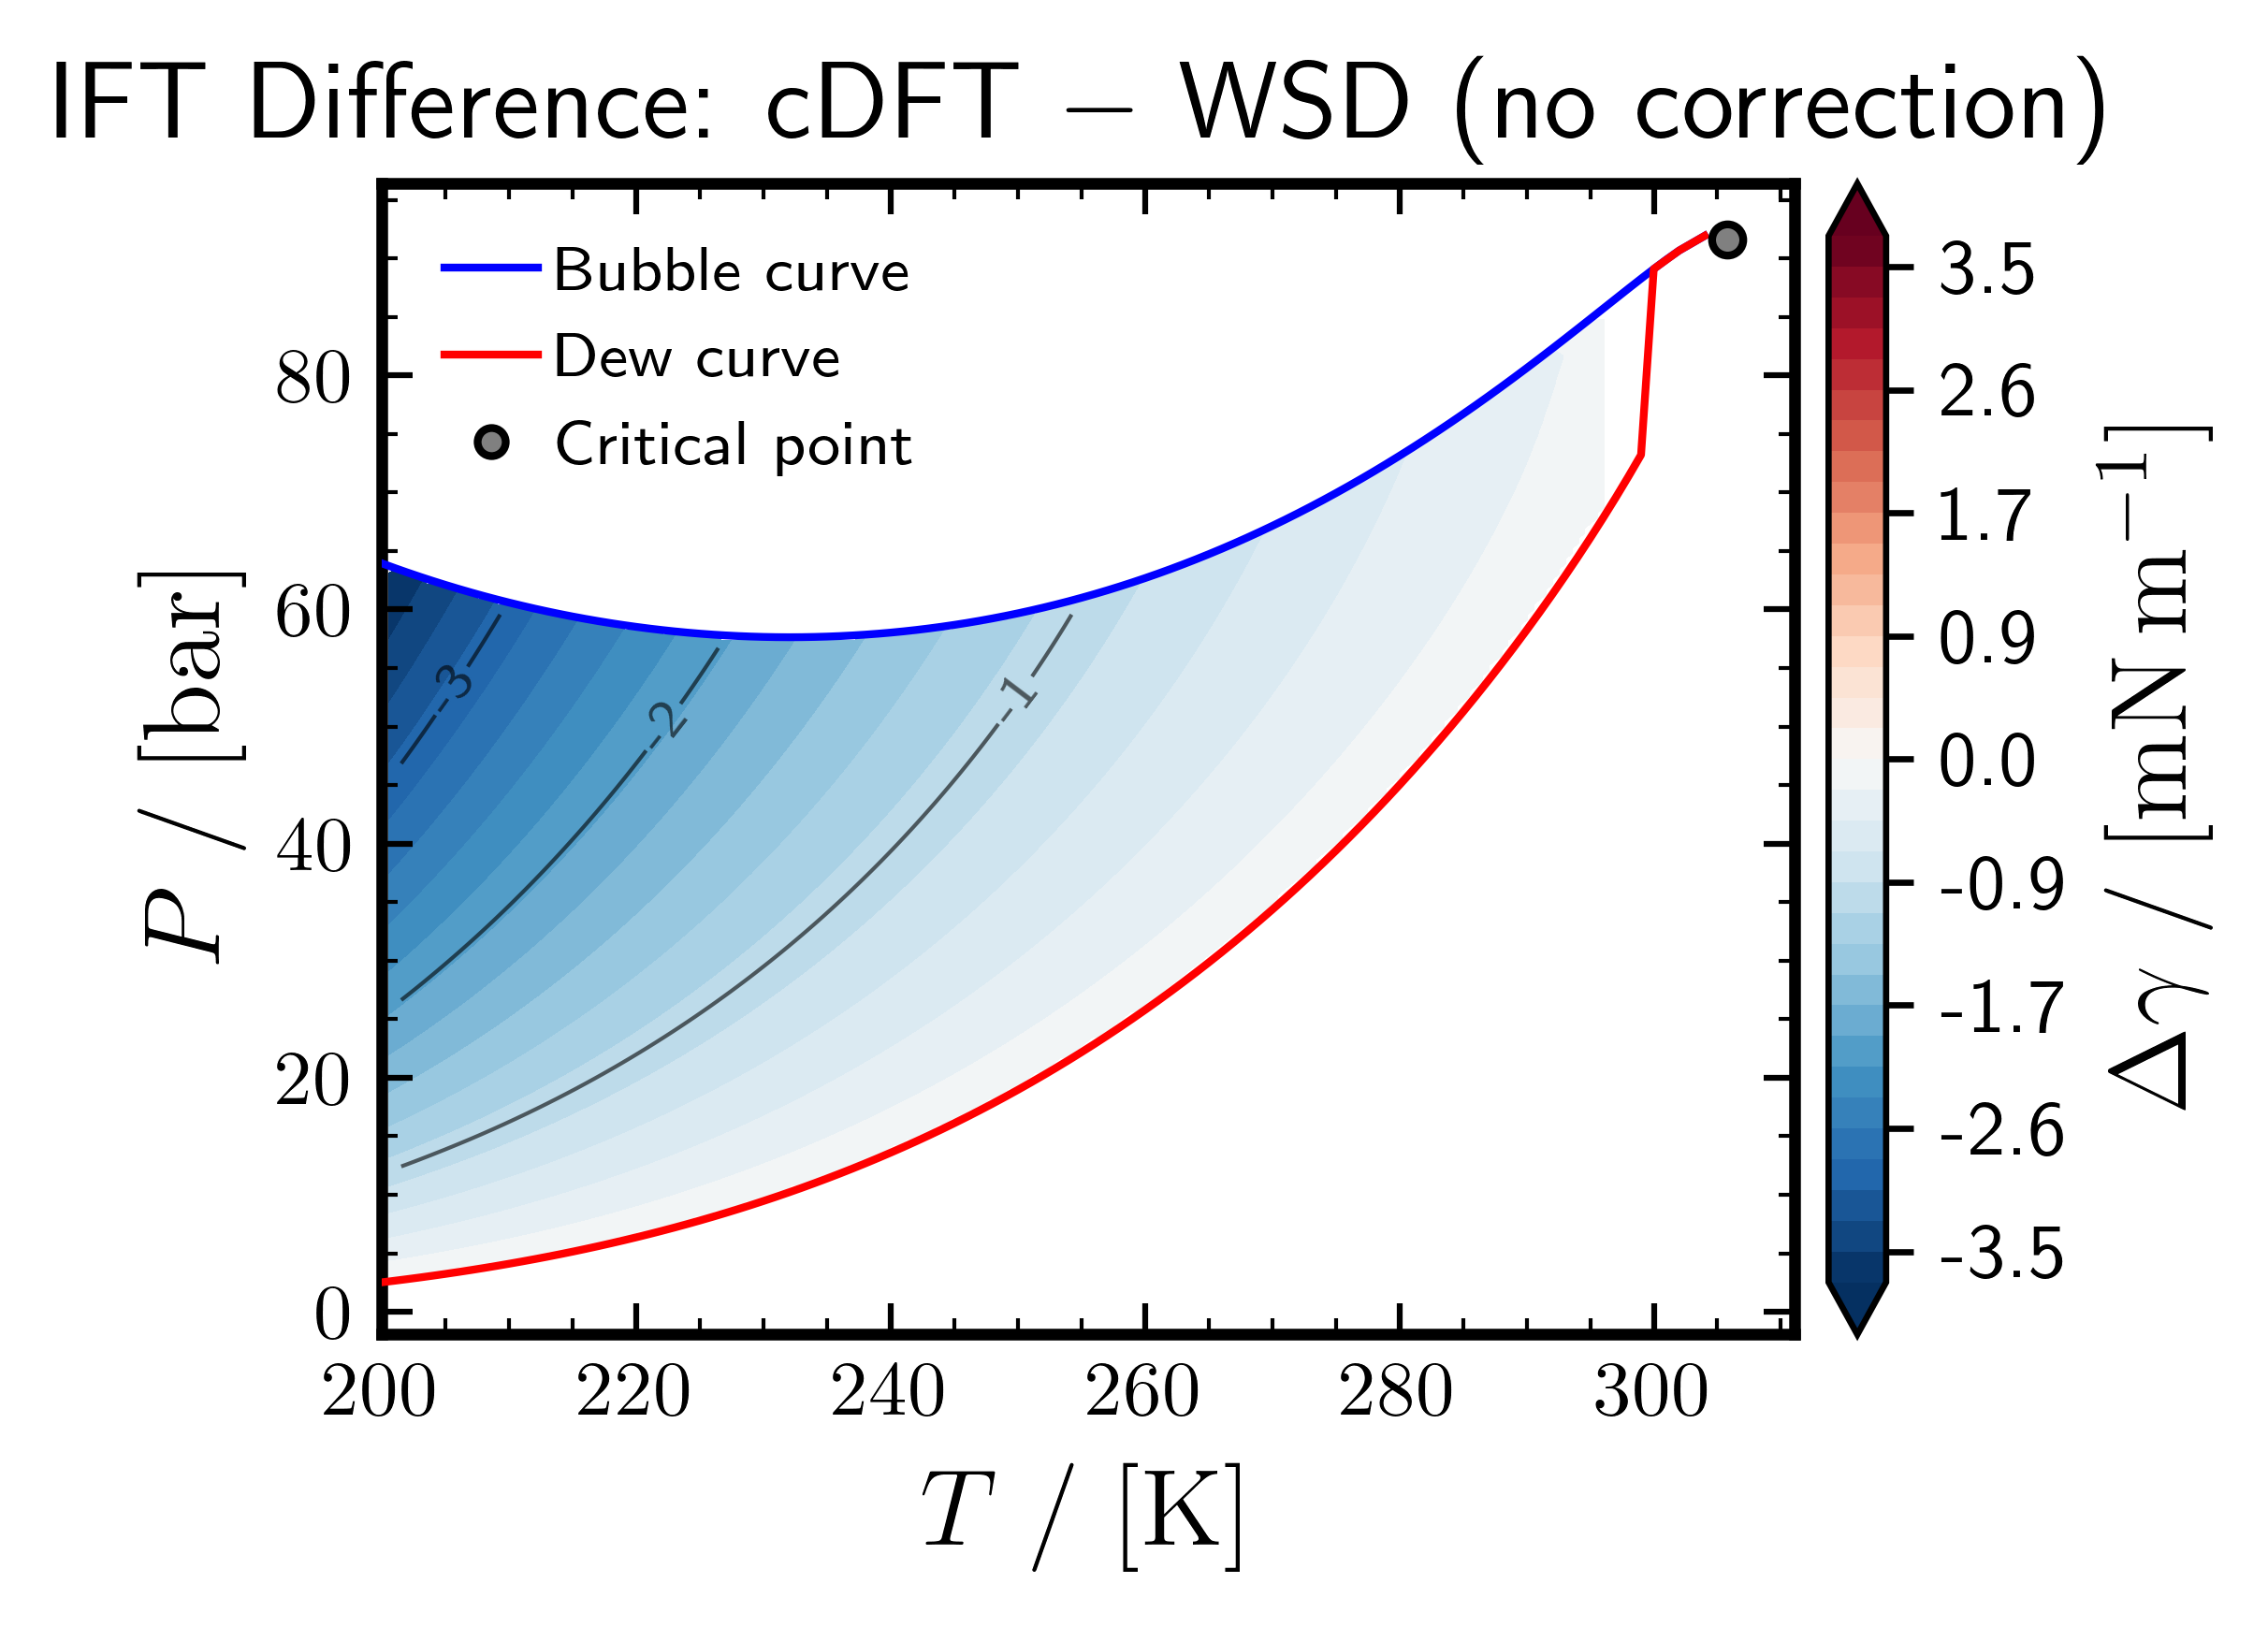

cDFT $-$ WSD (no correction): range = [-3.72, -0.02] mN/m


In [11]:
# --- Difference colormaps: cDFT vs Parachor, cDFT vs WSD (corrected), cDFT vs WSD (no correction) ---
# Sign convention: diff = cDFT - SEC
#   diff > 0  -->  SEC underpredicts relative to cDFT (the reference)
#   diff < 0  -->  SEC overpredicts relative to cDFT

from scipy.interpolate import griddata
from matplotlib.path import Path as MplPath
from scipy.ndimage import binary_erosion

# --- Extract cDFT scattered data ---
feed_key = list(VLE_DFT.keys())[0]
T_cdft, P_cdft, G_cdft = [], [], []
for T_K, data_list in VLE_DFT[feed_key]["interfacial_data"].items():
    for pt in data_list:
        if "gamma" in pt and not np.isnan(pt["gamma"]):
            T_cdft.append(pt["temperature"])
            P_cdft.append(pt["pressure"])
            G_cdft.append(pt["gamma"])

T_cdft = np.array(T_cdft)
P_cdft = np.array(P_cdft)
G_cdft = np.array(G_cdft)

# --- Extract SEC scattered data ---
T_para = np.array(data_parachor["T"])
P_para = np.array(data_parachor["P"])
G_para = np.array(data_parachor["gamma"])

T_wsd = np.array(data_wsd["T"])
P_wsd = np.array(data_wsd["P"])
G_wsd = np.array(data_wsd["gamma"])

T_wsd_nc = np.array(data_wsd_nocorr["T"])
P_wsd_nc = np.array(data_wsd_nocorr["P"])
G_wsd_nc = np.array(data_wsd_nocorr["gamma"])

# --- Common interpolation grid ---
T_all = np.concatenate([T_cdft, T_para, T_wsd, T_wsd_nc])
P_all = np.concatenate([P_cdft, P_para, P_wsd, P_wsd_nc])
grid_size = 200

T_grid = np.linspace(T_all.min(), T_all.max(), grid_size)
P_grid = np.linspace(P_all.min(), P_all.max(), grid_size)
T_mesh, P_mesh = np.meshgrid(T_grid, P_grid)

# Interpolate each method onto the common grid
G_cdft_mesh   = griddata((T_cdft, P_cdft), G_cdft, (T_mesh, P_mesh), method="cubic", fill_value=np.nan)
G_para_mesh   = griddata((T_para, P_para), G_para, (T_mesh, P_mesh), method="cubic", fill_value=np.nan)
G_wsd_mesh    = griddata((T_wsd, P_wsd),   G_wsd,  (T_mesh, P_mesh), method="cubic", fill_value=np.nan)
G_wsd_nc_mesh = griddata((T_wsd_nc, P_wsd_nc), G_wsd_nc, (T_mesh, P_mesh), method="cubic", fill_value=np.nan)

# --- Build phase envelope mask ---
feed = PT_results[feed_key]
env_T = [pt["T_K"] for pt in feed["bubble"]] + [pt["T_K"] for pt in feed["dew"]][::-1]
env_P = [pt["P_bar"] for pt in feed["bubble"]] + [pt["P_bar"] for pt in feed["dew"]][::-1]
envelope_path = MplPath(np.column_stack([env_T, env_P]))
grid_points = np.column_stack([T_mesh.ravel(), P_mesh.ravel()])
inside = envelope_path.contains_points(grid_points).reshape(T_mesh.shape)
inside_eroded = binary_erosion(inside, iterations=2)

# --- Compute differences ---
diff_pairs = [
    ("cDFT $-$ Parachor",            G_cdft_mesh, G_para_mesh),
    ("cDFT $-$ WSD (corrected)",     G_cdft_mesh, G_wsd_mesh),
    ("cDFT $-$ WSD (no correction)", G_cdft_mesh, G_wsd_nc_mesh),
]

isoline_step = 1  # same step as SEC/cDFT colormaps [mN/m]

for label, G_A, G_B in diff_pairs:
    diff = G_A - G_B
    diff_masked = np.ma.masked_where(~inside | np.isnan(diff), diff)
    
    if diff_masked.count() < 4:
        print(f"Skipping '{label}' — insufficient overlap data.")
        continue
    
    vmin = float(np.nanmin(diff_masked))
    vmax = float(np.nanmax(diff_masked))
    vlim = max(abs(vmin), abs(vmax))
    
    fig, ax = ps.plot_init()
    
    # Symmetric diverging colormap centered at 0
    levels_fill = np.linspace(-vlim, vlim, 35)
    cf = ax.contourf(T_mesh, P_mesh, diff_masked, levels=levels_fill,
                     cmap="RdBu_r", extend="both")
    
    # Eroded mask for isolines (same as SEC/cDFT colormaps)
    diff_eroded = np.ma.masked_where(~inside_eroded | np.isnan(diff), diff)
    
    # Iso-difference lines: same style as SEC/cDFT colormaps
    levels_lines = [n for n in range(-int(vlim), int(vlim) + 1, isoline_step)
                    if vmin <= n <= vmax]
    
    if levels_lines:
        cl = ax.contour(T_mesh, P_mesh, diff_eroded, levels=levels_lines,
                        colors="black", linestyles="solid", linewidths=ps.linewidth / 2, alpha=0.6)
        ax.clabel(cl, levels=levels_lines, inline=True,
                  fontsize=ps.label_fontsize / 2, fmt="%.0f",
                  inline_spacing=15, rightside_up=True)
    
    # Colorbar — auto ticks with fine format
    cbar = fig.colorbar(cf, ax=ax, pad=0.02, format="%.1f")
    cbar.set_label(r"$\Delta\gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
    cbar.ax.tick_params(labelsize=10)
    
    # Phase envelope overlay
    ax.plot([pt["T_K"] for pt in feed["bubble"]], [pt["P_bar"] for pt in feed["bubble"]],
            "b-", linewidth=ps.linewidth, label="Bubble curve", zorder=10)
    ax.plot([pt["T_K"] for pt in feed["dew"]], [pt["P_bar"] for pt in feed["dew"]],
            "r-", linewidth=ps.linewidth, label="Dew curve", zorder=10)
    ax.plot(feed["TC_K"], feed["PC_bar"], "o", markersize=4, zorder=15,
            markerfacecolor="grey", markeredgewidth=1, markeredgecolor="black", label="Critical point")
    
    ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P \; / \; [\mathrm{bar}]$", fontsize=ps.label_fontsize)
    ax.set_xlim(left=200)
    ax.minorticks_on()
    ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
    ax.set_title(f"IFT Difference: {label}", fontsize=ps.label_fontsize)
    
    fig.tight_layout()
    
    # Save
    safe_label = label.replace(" ", "_").replace("$", "").replace("-", "minus").replace("\\", "")
    plt.savefig(f"{CSV_FOLDER}/diff_{safe_label}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{CSV_FOLDER}/diff_{safe_label}.pdf", bbox_inches="tight")
    plt.show()
    
    print(f"{label}: range = [{vmin:.2f}, {vmax:.2f}] mN/m")

In [9]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 8.71 minutes
